# Phase 6: Model Interpretation

# Section 1 — Explainability Setup & Final Model Loading
## Objective

The objective of this section is to prepare the final FactoryGuard AI model and its supporting datasets for model interpretation and explainability.

We will load the final Random Forest model selected in Phase 5, the preprocessing pipeline, the processed training and testing datasets, and the final feature-name mapping.

We will also verify that the loaded model, dataset, and feature names are compatible before performing any explainability analysis.
## Why Are We Doing This?

Before interpreting the model, we need to ensure that we are working with the exact final model and feature configuration selected during Phase 5.

This verification helps us:

- Use the correct final Random Forest model.
- Confirm that the processed datasets contain the expected features.
- Maintain the correct mapping between model features and their names.
- Confirm that the final decision threshold is 0.50.
- Prevent errors caused by using an incorrect model, dataset, or feature configuration.

This provides a reliable foundation for all subsequent explainability and error-analysis steps.
## What Are We Doing?

In this section, we will:

1. Define the required project and report paths.
2. Load the final Random Forest model.
3. Load the preprocessing pipeline.
4. Load the processed training and testing datasets.
5. Separate features and the target variable.
6. Load the final feature-name mapping.
7. Verify the final model configuration.
8. Verify that the model and feature dimensions are compatible.
9. Confirm the test-set class distribution.
10. Save a setup summary for Phase 6.

In [162]:
from pathlib import Path
import pandas as pd
import joblib
import numpy as np

# ============================================================
# 1. Project paths
# ============================================================

PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"

PHASE6_REPORT_DIR = PROJECT_ROOT / "reports" / "06_Model_Interpretation"

TABLE_DIR = PHASE6_REPORT_DIR / "tables"
FIGURE_DIR = PHASE6_REPORT_DIR / "figures"

# Create Phase 6 report directories if they do not already exist
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT.resolve())
print("Phase 6 report directory:", PHASE6_REPORT_DIR.resolve())

Project root: C:\Users\bhard\FactoryGuard_AI
Phase 6 report directory: C:\Users\bhard\FactoryGuard_AI\reports\06_Model_Interpretation


In [163]:
# ============================================================
# 2. Load final model and preprocessing pipeline
# ============================================================

MODEL_PATH = MODEL_DIR / "final_factoryguard_model.pkl"
PIPELINE_PATH = MODEL_DIR / "preprocessing_pipeline.pkl"

final_model = joblib.load(MODEL_PATH)
preprocessing_pipeline = joblib.load(PIPELINE_PATH)

print("Final model loaded successfully.")
print("Preprocessing pipeline loaded successfully.")

Final model loaded successfully.
Preprocessing pipeline loaded successfully.


In [164]:
# ============================================================
# 3. Load processed datasets
# ============================================================

TRAIN_PATH = DATA_DIR / "train_ml_dataset.csv"
TEST_PATH = DATA_DIR / "test_ml_dataset.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training dataset shape:", train_df.shape)
print("Testing dataset shape :", test_df.shape)

Training dataset shape: (8000, 116)
Testing dataset shape : (2000, 116)


In [165]:
# ============================================================
# 4. Separate features and target
# ============================================================

TARGET = "final_pass"

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nX_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 115)
y_train shape: (8000,)

X_test shape: (2000, 115)
y_test shape: (2000,)


In [166]:
# ============================================================
# 5. Load final feature names
# ============================================================

FEATURE_NAMES_PATH = DATA_DIR / "final_feature_names.csv"

feature_names_df = pd.read_csv(FEATURE_NAMES_PATH)

print("Feature-name file shape:", feature_names_df.shape)
print("\nColumns:")
print(feature_names_df.columns.tolist())

feature_names_df.head()

Feature-name file shape: (115, 1)

Columns:
['Feature']


,Feature
0,numerical__machine_age_yrs
1,numerical__temp_c
2,numerical__humidity_pct
3,numerical__process_speed_units_hr
4,numerical__defect_severity_0to3


In [167]:
# ============================================================
# 6. Extract feature names
# ============================================================

if "feature_name" in feature_names_df.columns:
    feature_names = feature_names_df["feature_name"].tolist()
else:
    # Use the first column if the file contains a single unnamed/
    # differently named feature-name column.
    feature_names = feature_names_df.iloc[:, 0].tolist()

print("Number of feature names:", len(feature_names))
print("\nFirst 10 feature names:")
print(feature_names[:10])

Number of feature names: 115

First 10 feature names:
['numerical__machine_age_yrs', 'numerical__temp_c', 'numerical__humidity_pct', 'numerical__process_speed_units_hr', 'numerical__defect_severity_0to3', 'numerical__decision_rework', 'numerical__total_cycle_time_min', 'numerical__energy_kwh', 'numerical__cost_usd', 'numerical__event_hour']


In [168]:
# ============================================================
# 7. Verify final model configuration
# ============================================================

print("Model type:")
print(type(final_model).__name__)

print("\nModel parameters:")
print("n_estimators      :", final_model.n_estimators)
print("max_depth         :", final_model.max_depth)
print("max_features      :", final_model.max_features)
print("min_samples_split :", final_model.min_samples_split)
print("min_samples_leaf  :", final_model.min_samples_leaf)
print("class_weight      :", final_model.class_weight)
print("random_state      :", final_model.random_state)

# Final operating threshold selected in Phase 5
FINAL_THRESHOLD = 0.50

print("\nFinal decision threshold:", FINAL_THRESHOLD)

Model type:
RandomForestClassifier

Model parameters:
n_estimators      : 188
max_depth         : 12
max_features      : sqrt
min_samples_split : 5
min_samples_leaf  : 2
class_weight      : balanced
random_state      : 42

Final decision threshold: 0.5


In [169]:
# ============================================================
# 8. Verify feature compatibility
# ============================================================

model_feature_count = final_model.n_features_in_
dataset_feature_count = X_test.shape[1]
feature_name_count = len(feature_names)

print("Model expected features :", model_feature_count)
print("Dataset feature count   :", dataset_feature_count)
print("Feature-name count      :", feature_name_count)

assert model_feature_count == dataset_feature_count, (
    "Mismatch between model features and dataset features."
)

assert model_feature_count == feature_name_count, (
    "Mismatch between model features and feature-name list."
)

print("\nFeature compatibility check: PASSED")

Model expected features : 115
Dataset feature count   : 115
Feature-name count      : 115

Feature compatibility check: PASSED


In [170]:
# ============================================================
# 9. Verify target distribution
# ============================================================

target_distribution = (
    y_test
    .value_counts()
    .sort_index()
    .to_frame("count")
)

target_distribution["percentage"] = (
    target_distribution["count"] / len(y_test) * 100
)

target_distribution

,count,percentage
final_pass,,
0,248,12.4
1,1752,87.6


In [171]:
# ============================================================
# 10. Save Phase 6 setup summary
# ============================================================

setup_summary = pd.DataFrame({
    "Parameter": [
        "Model",
        "Training Records",
        "Testing Records",
        "Number of Features",
        "Target Variable",
        "Final Decision Threshold",
        "Class 0 Percentage",
        "Class 1 Percentage",
        "n_estimators",
        "max_depth",
        "max_features",
        "min_samples_split",
        "min_samples_leaf",
        "class_weight",
        "random_state"
    ],
    "Value": [
        type(final_model).__name__,
        len(X_train),
        len(X_test),
        model_feature_count,
        TARGET,
        FINAL_THRESHOLD,
        target_distribution.loc[0, "percentage"],
        target_distribution.loc[1, "percentage"],
        final_model.n_estimators,
        final_model.max_depth,
        final_model.max_features,
        final_model.min_samples_split,
        final_model.min_samples_leaf,
        str(final_model.class_weight),
        final_model.random_state
    ]
})

setup_summary.to_csv(
    TABLE_DIR / "model_interpretation_setup.csv",
    index=False
)

setup_summary

,Parameter,Value
0,Model,RandomForestClassifier
1,Training Records,8000
2,Testing Records,2000
3,Number of Features,115
4,Target Variable,final_pass
5,Final Decision Threshold,0.5
6,Class 0 Percentage,12.4
7,Class 1 Percentage,87.6
8,n_estimators,188
9,max_depth,12


In [172]:
# ============================================================
# 11. Final setup verification
# ============================================================

print("=" * 60)
print("PHASE 6 - SECTION 1 SETUP VERIFICATION")
print("=" * 60)

print(f"Model                : {type(final_model).__name__}")
print(f"Training records     : {len(X_train):,}")
print(f"Testing records      : {len(X_test):,}")
print(f"Features             : {model_feature_count}")
print(f"Target               : {TARGET}")
print(f"Decision threshold   : {FINAL_THRESHOLD}")
print(f"Feature check        : PASSED")
print(f"Model loaded         : YES")
print(f"Pipeline loaded      : YES")
print("=" * 60)

PHASE 6 - SECTION 1 SETUP VERIFICATION
Model                : RandomForestClassifier
Training records     : 8,000
Testing records      : 2,000
Features             : 115
Target               : final_pass
Decision threshold   : 0.5
Feature check        : PASSED
Model loaded         : YES
Pipeline loaded      : YES


## Summary & Observations

- The final Random Forest model was successfully loaded from `models/final_factoryguard_model.pkl`.
- The preprocessing pipeline was successfully loaded from `models/preprocessing_pipeline.pkl`.
- The training and testing datasets were successfully loaded.
- The final model expects the same number of features as the processed test dataset.
- The feature-name mapping was successfully verified.
- The final operating decision threshold remains **0.50**.
- A Phase 6 setup summary was saved to:

`reports/06_Model_Interpretation/tables/model_interpretation_setup.csv`

### Key Insight

The explainability analysis will be performed on the **same final Random Forest model and feature configuration selected in Phase 5**, ensuring consistency between model evaluation and model interpretation.

# Section 2 — Global Feature Importance
## Objective

The objective of this section is to identify which features contribute most strongly to the predictions made by the final Random Forest model.

We will extract the model's built-in feature importance values, map them to the corresponding feature names, rank all features, and identify the most important features used by the model.
## Why Are We Doing This?

A machine-learning model can make accurate predictions, but it is also important to understand which input variables are driving those predictions.

Feature importance helps us answer:

> Which features does FactoryGuard AI rely on most when making classification decisions?

This is useful because it:

- Improves model interpretability.
- Helps identify the most influential manufacturing variables.
- Makes the model easier to explain during an interview.
- Provides useful information for further feature analysis.
- Helps connect the machine-learning results with the manufacturing problem.
## What Are We Doing?

In this section, we will:

1. Extract feature importance values from the final Random Forest.
2. Map each importance value to its corresponding feature name.
3. Rank all features from most to least important.
4. Save the complete feature-importance table.
5. Identify the Top 15 most important features.
6. Visualize the Top 15 features.
7. Save the visualization for the Phase 6 report.

In [173]:
# ============================================================
# 1. Extract feature importance from the final Random Forest
# ============================================================

feature_importance = final_model.feature_importances_

print("Number of feature importance values:", len(feature_importance))
print("Number of feature names:", len(feature_names))

Number of feature importance values: 115
Number of feature names: 115


In [174]:
# ============================================================
# 2. Create feature importance DataFrame
# ============================================================

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importance
})

# Sort from highest to lowest importance
feature_importance_df = (
    feature_importance_df
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

# Add rank
feature_importance_df.insert(
    0,
    "rank",
    range(1, len(feature_importance_df) + 1)
)

feature_importance_df.head(15)

,rank,feature,importance
0,1,numerical__cost_usd,0.149274
1,2,numerical__defect_severity_0to3,0.107806
2,3,numerical__energy_kwh,0.073306
3,4,numerical__total_cycle_time_min,0.072909
4,5,categorical__defect_type_none,0.061021
5,6,numerical__machine_age_yrs,0.052758
6,7,numerical__process_speed_units_hr,0.040828
7,8,numerical__humidity_pct,0.039717
8,9,numerical__temp_c,0.038216
9,10,numerical__event_hour,0.028947


In [175]:
# ============================================================
# 3. Verify feature importance values
# ============================================================

print("Total features:", len(feature_importance_df))
print("Importance sum:", feature_importance_df["importance"].sum())
print("Minimum importance:", feature_importance_df["importance"].min())
print("Maximum importance:", feature_importance_df["importance"].max())

Total features: 115
Importance sum: 1.0000000000000002
Minimum importance: 0.0005548045128912776
Maximum importance: 0.1492736265011496


In [176]:
# ============================================================
# 4. Display Top 15 features
# ============================================================

top_15_features = feature_importance_df.head(15).copy()

top_15_features

,rank,feature,importance
0,1,numerical__cost_usd,0.149274
1,2,numerical__defect_severity_0to3,0.107806
2,3,numerical__energy_kwh,0.073306
3,4,numerical__total_cycle_time_min,0.072909
4,5,categorical__defect_type_none,0.061021
5,6,numerical__machine_age_yrs,0.052758
6,7,numerical__process_speed_units_hr,0.040828
7,8,numerical__humidity_pct,0.039717
8,9,numerical__temp_c,0.038216
9,10,numerical__event_hour,0.028947


In [177]:
# ============================================================
# 5. Save complete feature importance table
# ============================================================

FEATURE_IMPORTANCE_PATH = TABLE_DIR / "feature_importance.csv"

feature_importance_df.to_csv(
    FEATURE_IMPORTANCE_PATH,
    index=False
)

print(f"Feature importance table saved to:")
print(FEATURE_IMPORTANCE_PATH)

Feature importance table saved to:
..\reports\06_Model_Interpretation\tables\feature_importance.csv


In [178]:
# ============================================================
# 6. Save Top 15 feature importance table
# ============================================================

TOP_FEATURES_PATH = TABLE_DIR / "top_15_features.csv"

top_15_features.to_csv(
    TOP_FEATURES_PATH,
    index=False
)

print(f"Top 15 feature table saved to:")
print(TOP_FEATURES_PATH)

Top 15 feature table saved to:
..\reports\06_Model_Interpretation\tables\top_15_features.csv


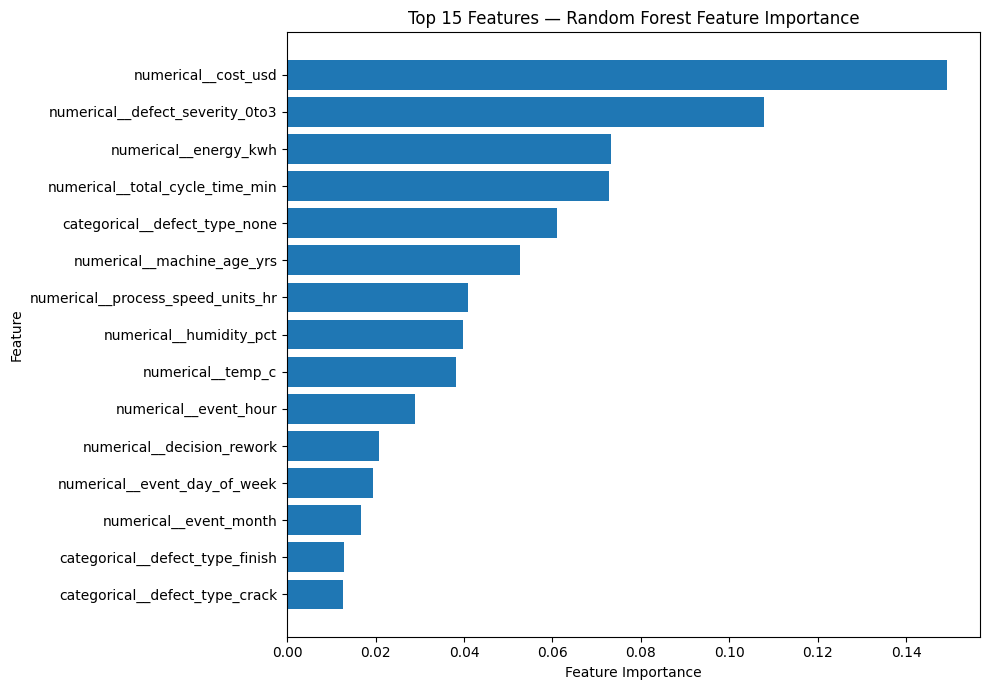

Figure saved to:
..\reports\06_Model_Interpretation\figures\top_15_feature_importance.png


In [179]:
# ============================================================
# 7. Plot Top 15 feature importance
# ============================================================

import matplotlib.pyplot as plt

plot_df = top_15_features.sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"],
    plot_df["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features — Random Forest Feature Importance")

plt.tight_layout()

FEATURE_IMPORTANCE_FIGURE = FIGURE_DIR / "top_15_feature_importance.png"

plt.savefig(
    FEATURE_IMPORTANCE_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to:")
print(FEATURE_IMPORTANCE_FIGURE)

In [180]:
# ============================================================
# 8. Analyze importance concentration
# ============================================================

top_5_importance = feature_importance_df.head(5)["importance"].sum()
top_10_importance = feature_importance_df.head(10)["importance"].sum()
top_15_importance = feature_importance_df.head(15)["importance"].sum()

importance_concentration = pd.DataFrame({
    "Feature Group": [
        "Top 5",
        "Top 10",
        "Top 15"
    ],
    "Cumulative Importance": [
        top_5_importance,
        top_10_importance,
        top_15_importance
    ]
})

importance_concentration

,Feature Group,Cumulative Importance
0,Top 5,0.464315
1,Top 10,0.664782
2,Top 15,0.747187


In [181]:
# ============================================================
# 9. Save importance concentration analysis
# ============================================================

CONCENTRATION_PATH = TABLE_DIR / "feature_importance_concentration.csv"

importance_concentration.to_csv(
    CONCENTRATION_PATH,
    index=False
)

print(f"Importance concentration table saved to:")
print(CONCENTRATION_PATH)

Importance concentration table saved to:
..\reports\06_Model_Interpretation\tables\feature_importance_concentration.csv


In [182]:
# ============================================================
# 10. Section summary
# ============================================================

print("=" * 60)
print("SECTION 2 — GLOBAL FEATURE IMPORTANCE")
print("=" * 60)

print(f"Total features analyzed : {len(feature_importance_df)}")
print(f"Top 5 importance        : {top_5_importance:.4f}")
print(f"Top 10 importance       : {top_10_importance:.4f}")
print(f"Top 15 importance       : {top_15_importance:.4f}")

print("\nTop 5 features:")

for _, row in feature_importance_df.head(5).iterrows():
    print(
        f"{int(row['rank'])}. "
        f"{row['feature']} → "
        f"{row['importance']:.4f}"
    )

print("=" * 60)

SECTION 2 — GLOBAL FEATURE IMPORTANCE
Total features analyzed : 115
Top 5 importance        : 0.4643
Top 10 importance       : 0.6648
Top 15 importance       : 0.7472

Top 5 features:
1. numerical__cost_usd → 0.1493
2. numerical__defect_severity_0to3 → 0.1078
3. numerical__energy_kwh → 0.0733
4. numerical__total_cycle_time_min → 0.0729
5. categorical__defect_type_none → 0.0610


## Summary & Observations

### Summary

The final Random Forest's built-in feature importance values were extracted and mapped to the corresponding feature names.

The features were ranked from highest to lowest importance, and the Top 15 features were visualized.

The following outputs were saved:

- `reports/06_Model_Interpretation/tables/feature_importance.csv`
- `reports/06_Model_Interpretation/tables/top_15_features.csv`
- `reports/06_Model_Interpretation/tables/feature_importance_concentration.csv`
- `reports/06_Model_Interpretation/figures/top_15_feature_importance.png`

### Observations

- Feature importance provides a global view of which variables the Random Forest relies on most.
- The Top 15 features represent the strongest contributors according to the model's built-in importance measure.
- The cumulative importance of the Top 5, Top 10, and Top 15 features helps determine whether the model's predictive behavior is concentrated in a small number of variables.

### Key Insight

Feature importance tells us **which features are important to the model**, but it does not by itself explain **whether a feature increases or decreases the probability of a particular class**.

That directional analysis will be investigated in the next sections.

# Section 3 — Top Feature Analysis
## Objective

The objective of this section is to investigate the characteristics of the most important features identified by the Random Forest model.

We will examine the Top 15 features and compare their behavior across the two target classes to understand why these features may be useful for prediction.
## Why Are We Doing This?

Feature importance tells us which features are important to the model, but importance alone does not tell us what those features represent or how their values differ between the two classes.

Analyzing the most important features helps us:

- Understand the meaning of the features driving the model.
- Compare important features across the two target classes.
- Identify differences in feature distributions between classes.
- Connect model behavior with manufacturing-related patterns.
- Prepare a stronger business and interview-level explanation of the model.
## What Are We Doing?

In this section, we will:

1. Load the Top 15 feature-importance results.
2. Inspect the feature names and data types.
3. Classify the important features based on their representation in the processed dataset.
4. Compare feature values between class 0 and class 1.
5. Calculate class-wise statistics for the Top 15 features.
6. Identify the features showing the largest differences between the two classes.
7. Create visualizations for the most important features.
8. Save the analysis tables and important figures.

In [183]:
# ============================================================
# 1. Load Top 15 feature importance results
# ============================================================

TOP_FEATURES_PATH = TABLE_DIR / "top_15_features.csv"

top_15_features = pd.read_csv(TOP_FEATURES_PATH)

top_15_features

,rank,feature,importance
0,1,numerical__cost_usd,0.149274
1,2,numerical__defect_severity_0to3,0.107806
2,3,numerical__energy_kwh,0.073306
3,4,numerical__total_cycle_time_min,0.072909
4,5,categorical__defect_type_none,0.061021
5,6,numerical__machine_age_yrs,0.052758
6,7,numerical__process_speed_units_hr,0.040828
7,8,numerical__humidity_pct,0.039717
8,9,numerical__temp_c,0.038216
9,10,numerical__event_hour,0.028947


In [184]:
# ============================================================
# 2. Inspect Top feature names
# ============================================================

print("Top 15 features:\n")

for _, row in top_15_features.iterrows():
    print(
        f"{int(row['rank']):2d}. "
        f"{row['feature']} "
        f"→ importance = {row['importance']:.4f}"
    )

Top 15 features:

 1. numerical__cost_usd → importance = 0.1493
 2. numerical__defect_severity_0to3 → importance = 0.1078
 3. numerical__energy_kwh → importance = 0.0733
 4. numerical__total_cycle_time_min → importance = 0.0729
 5. categorical__defect_type_none → importance = 0.0610
 6. numerical__machine_age_yrs → importance = 0.0528
 7. numerical__process_speed_units_hr → importance = 0.0408
 8. numerical__humidity_pct → importance = 0.0397
 9. numerical__temp_c → importance = 0.0382
10. numerical__event_hour → importance = 0.0289
11. numerical__decision_rework → importance = 0.0207
12. numerical__event_day_of_week → importance = 0.0194
13. numerical__event_month → importance = 0.0167
14. categorical__defect_type_finish → importance = 0.0129
15. categorical__defect_type_crack → importance = 0.0126


In [185]:
# ============================================================
# 3. Inspect data types of Top 15 features
# ============================================================

top_feature_names = top_15_features["feature"].tolist()

feature_type_info = pd.DataFrame({
    "feature": top_feature_names,
    "dtype": [X_train[feature].dtype for feature in top_feature_names],
    "unique_values": [
        X_train[feature].nunique()
        for feature in top_feature_names
    ]
})

feature_type_info

,feature,dtype,unique_values
0,numerical__cost_usd,float64,2713
1,numerical__defect_severity_0to3,float64,4
2,numerical__energy_kwh,float64,1078
3,numerical__total_cycle_time_min,float64,653
4,categorical__defect_type_none,float64,2
5,numerical__machine_age_yrs,float64,1273
6,numerical__process_speed_units_hr,float64,1158
7,numerical__humidity_pct,float64,592
8,numerical__temp_c,float64,210
9,numerical__event_hour,float64,24


In [186]:
# ============================================================
# 4. Calculate class-wise statistics
# ============================================================

class_statistics = []

for feature in top_feature_names:

    class_0_values = X_train.loc[y_train == 0, feature]
    class_1_values = X_train.loc[y_train == 1, feature]

    class_statistics.append({
        "feature": feature,
        "importance": top_15_features.loc[
            top_15_features["feature"] == feature,
            "importance"
        ].iloc[0],
        "class_0_mean": class_0_values.mean(),
        "class_1_mean": class_1_values.mean(),
        "class_0_median": class_0_values.median(),
        "class_1_median": class_1_values.median(),
        "absolute_mean_difference": abs(
            class_0_values.mean() - class_1_values.mean()
        )
    })

class_statistics_df = (
    pd.DataFrame(class_statistics)
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

class_statistics_df

,feature,importance,class_0_mean,class_1_mean,class_0_median,class_1_median,absolute_mean_difference
0,numerical__cost_usd,0.149274,0.995913,-0.140812,-0.159512,-0.251963,1.136725
1,numerical__defect_severity_0to3,0.107806,0.775388,-0.109632,-0.400416,-0.400416,0.885020
2,numerical__energy_kwh,0.073306,0.399081,-0.056426,-0.023717,-0.187073,0.455506
3,numerical__total_cycle_time_min,0.072909,0.449954,-0.063619,-0.161427,-0.284954,0.513572
4,categorical__defect_type_none,0.061021,0.599395,0.872735,1.000000,1.000000,0.273341
5,numerical__machine_age_yrs,0.052758,0.209736,-0.029655,0.165765,-0.024613,0.239391
6,numerical__process_speed_units_hr,0.040828,0.106231,-0.015020,0.073041,-0.030767,0.121251
7,numerical__humidity_pct,0.039717,0.010154,-0.001436,0.050702,0.050702,0.011590
8,numerical__temp_c,0.038216,0.007021,-0.000993,-0.119951,-0.097077,0.008014
9,numerical__event_hour,0.028947,-0.065820,0.009306,-0.081709,0.062749,0.075126


In [187]:
# ============================================================
# 5. Determine direction of class difference
# ============================================================

class_statistics_df["higher_mean_class"] = np.where(
    class_statistics_df["class_0_mean"] >
    class_statistics_df["class_1_mean"],
    "Class 0",
    "Class 1"
)

class_statistics_df

,feature,importance,class_0_mean,class_1_mean,class_0_median,class_1_median,absolute_mean_difference,higher_mean_class
0,numerical__cost_usd,0.149274,0.995913,-0.140812,-0.159512,-0.251963,1.136725,Class 0
1,numerical__defect_severity_0to3,0.107806,0.775388,-0.109632,-0.400416,-0.400416,0.885020,Class 0
2,numerical__energy_kwh,0.073306,0.399081,-0.056426,-0.023717,-0.187073,0.455506,Class 0
3,numerical__total_cycle_time_min,0.072909,0.449954,-0.063619,-0.161427,-0.284954,0.513572,Class 0
4,categorical__defect_type_none,0.061021,0.599395,0.872735,1.000000,1.000000,0.273341,Class 1
5,numerical__machine_age_yrs,0.052758,0.209736,-0.029655,0.165765,-0.024613,0.239391,Class 0
6,numerical__process_speed_units_hr,0.040828,0.106231,-0.015020,0.073041,-0.030767,0.121251,Class 0
7,numerical__humidity_pct,0.039717,0.010154,-0.001436,0.050702,0.050702,0.011590,Class 0
8,numerical__temp_c,0.038216,0.007021,-0.000993,-0.119951,-0.097077,0.008014,Class 0
9,numerical__event_hour,0.028947,-0.065820,0.009306,-0.081709,0.062749,0.075126,Class 1


In [188]:
# ============================================================
# 6. Save Top feature class-wise analysis
# ============================================================

TOP_FEATURE_ANALYSIS_PATH = (
    TABLE_DIR / "top_feature_class_analysis.csv"
)

class_statistics_df.to_csv(
    TOP_FEATURE_ANALYSIS_PATH,
    index=False
)

print("Saved to:")
print(TOP_FEATURE_ANALYSIS_PATH)

Saved to:
..\reports\06_Model_Interpretation\tables\top_feature_class_analysis.csv


In [189]:
# ============================================================
# 7. Features with largest class-wise differences
# ============================================================

largest_difference_df = (
    class_statistics_df
    .sort_values(
        "absolute_mean_difference",
        ascending=False
    )
    .reset_index(drop=True)
)

largest_difference_df.head(10)

,feature,importance,class_0_mean,class_1_mean,class_0_median,class_1_median,absolute_mean_difference,higher_mean_class
0,numerical__cost_usd,0.149274,0.995913,-0.140812,-0.159512,-0.251963,1.136725,Class 0
1,numerical__defect_severity_0to3,0.107806,0.775388,-0.109632,-0.400416,-0.400416,0.885020,Class 0
2,numerical__total_cycle_time_min,0.072909,0.449954,-0.063619,-0.161427,-0.284954,0.513572,Class 0
3,numerical__energy_kwh,0.073306,0.399081,-0.056426,-0.023717,-0.187073,0.455506,Class 0
4,categorical__defect_type_none,0.061021,0.599395,0.872735,1.000000,1.000000,0.273341,Class 1
5,numerical__machine_age_yrs,0.052758,0.209736,-0.029655,0.165765,-0.024613,0.239391,Class 0
6,numerical__decision_rework,0.020690,0.177830,-0.025143,-0.570229,-0.570229,0.202974,Class 0
7,numerical__process_speed_units_hr,0.040828,0.106231,-0.015020,0.073041,-0.030767,0.121251,Class 0
8,numerical__event_hour,0.028947,-0.065820,0.009306,-0.081709,0.062749,0.075126,Class 1
9,categorical__defect_type_crack,0.012621,0.086781,0.023256,0.000000,0.000000,0.063525,Class 0


In [190]:
# ============================================================
# 8. Save largest class-difference analysis
# ============================================================

LARGEST_DIFFERENCE_PATH = (
    TABLE_DIR / "top_feature_class_differences.csv"
)

largest_difference_df.to_csv(
    LARGEST_DIFFERENCE_PATH,
    index=False
)

print("Saved to:")
print(LARGEST_DIFFERENCE_PATH)

Saved to:
..\reports\06_Model_Interpretation\tables\top_feature_class_differences.csv


In [191]:
# ============================================================
# 9. Select Top 5 features
# ============================================================

top_5_features = top_15_features.head(5)["feature"].tolist()

print("Features selected for visualization:")

for feature in top_5_features:
    print("-", feature)

Features selected for visualization:
- numerical__cost_usd
- numerical__defect_severity_0to3
- numerical__energy_kwh
- numerical__total_cycle_time_min
- categorical__defect_type_none


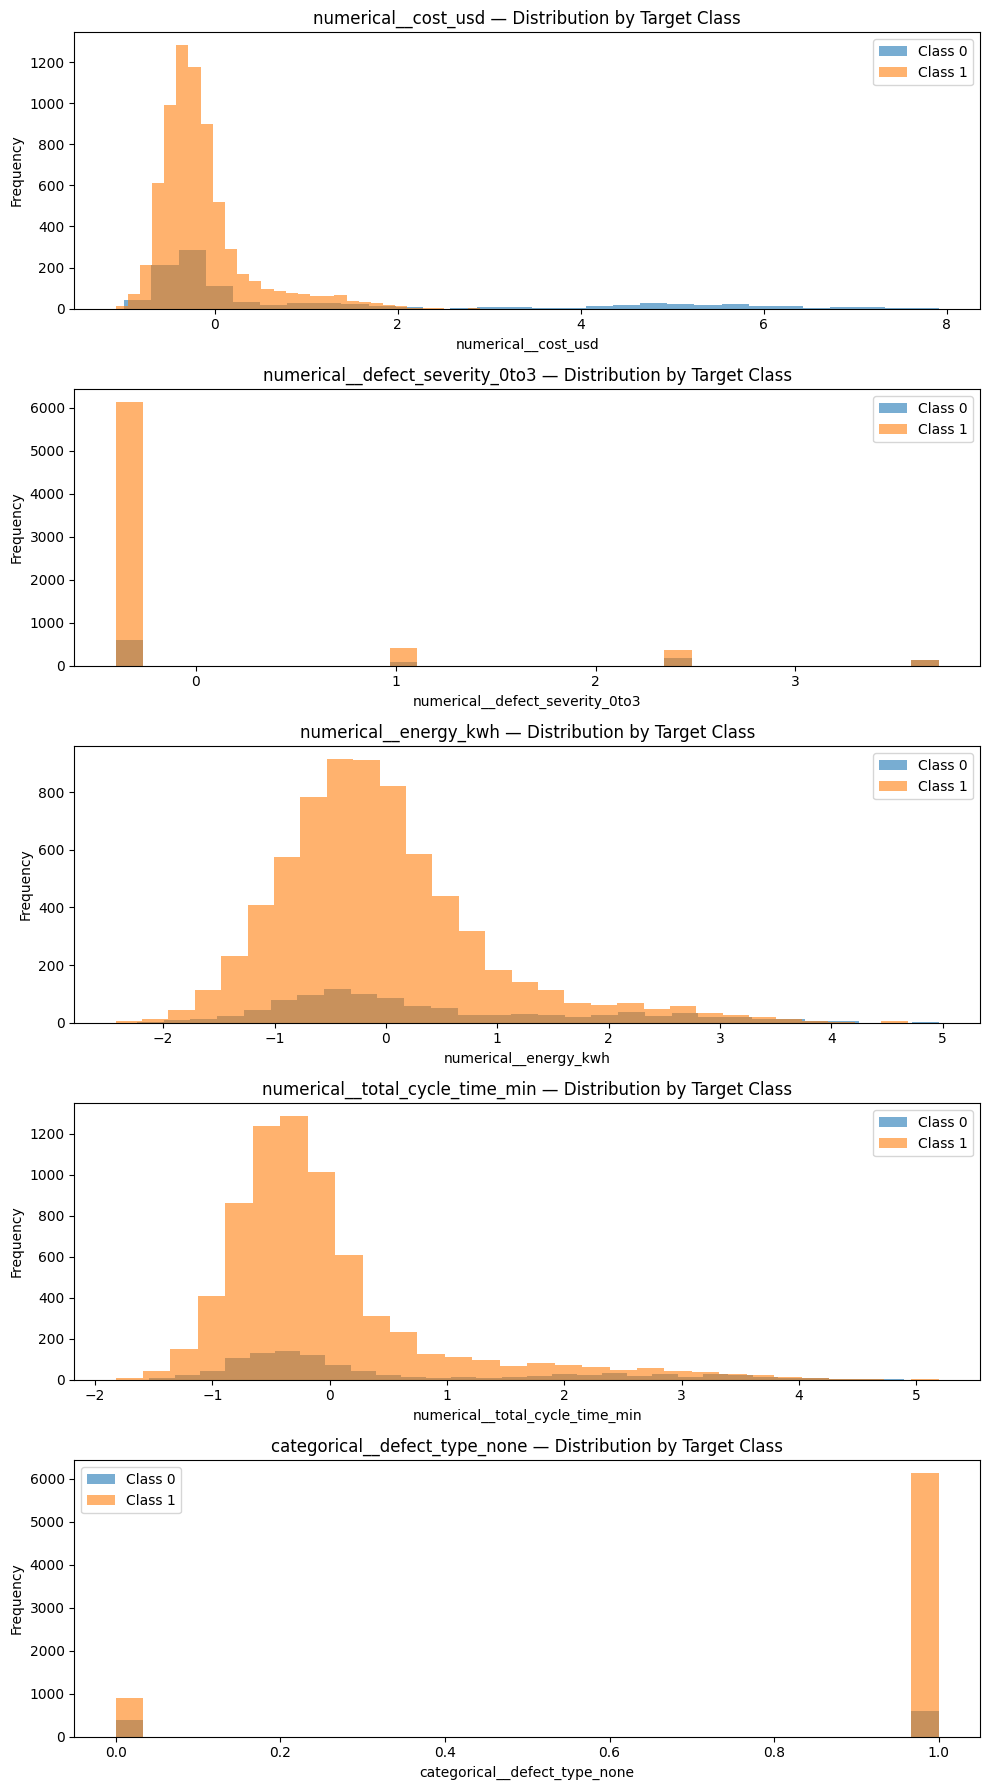

Figure saved to:
..\reports\06_Model_Interpretation\figures\top_5_feature_distributions.png


In [192]:
# ============================================================
# 10. Plot Top 5 feature distributions by target class
# ============================================================

fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(10, 18)
)

for ax, feature in zip(axes, top_5_features):

    class_0_values = X_train.loc[y_train == 0, feature]
    class_1_values = X_train.loc[y_train == 1, feature]

    ax.hist(
        class_0_values,
        bins=30,
        alpha=0.6,
        label="Class 0"
    )

    ax.hist(
        class_1_values,
        bins=30,
        alpha=0.6,
        label="Class 1"
    )

    ax.set_title(f"{feature} — Distribution by Target Class")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()

TOP_FEATURE_DISTRIBUTIONS_FIGURE = (
    FIGURE_DIR / "top_5_feature_distributions.png"
)

plt.savefig(
    TOP_FEATURE_DISTRIBUTIONS_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(TOP_FEATURE_DISTRIBUTIONS_FIGURE)

In [193]:
# ============================================================
# 11. Class mean comparison for Top 10 features
# ============================================================

top_10_class_comparison = (
    class_statistics_df
    .head(10)
    [["feature", "importance",
      "class_0_mean",
      "class_1_mean",
      "absolute_mean_difference"]]
)

top_10_class_comparison

,feature,importance,class_0_mean,class_1_mean,absolute_mean_difference
0,numerical__cost_usd,0.149274,0.995913,-0.140812,1.136725
1,numerical__defect_severity_0to3,0.107806,0.775388,-0.109632,0.885020
2,numerical__energy_kwh,0.073306,0.399081,-0.056426,0.455506
3,numerical__total_cycle_time_min,0.072909,0.449954,-0.063619,0.513572
4,categorical__defect_type_none,0.061021,0.599395,0.872735,0.273341
5,numerical__machine_age_yrs,0.052758,0.209736,-0.029655,0.239391
6,numerical__process_speed_units_hr,0.040828,0.106231,-0.015020,0.121251
7,numerical__humidity_pct,0.039717,0.010154,-0.001436,0.011590
8,numerical__temp_c,0.038216,0.007021,-0.000993,0.008014
9,numerical__event_hour,0.028947,-0.065820,0.009306,0.075126


In [194]:
# ============================================================
# 12. Save Top 10 class comparison
# ============================================================

TOP_10_COMPARISON_PATH = (
    TABLE_DIR / "top_10_feature_class_comparison.csv"
)

top_10_class_comparison.to_csv(
    TOP_10_COMPARISON_PATH,
    index=False
)

print("Saved to:")
print(TOP_10_COMPARISON_PATH)

Saved to:
..\reports\06_Model_Interpretation\tables\top_10_feature_class_comparison.csv


In [195]:
# ============================================================
# 13. Section summary
# ============================================================

print("=" * 65)
print("SECTION 3 — TOP FEATURE ANALYSIS")
print("=" * 65)

print(f"Features analyzed : {len(top_15_features)}")

print("\nTop 5 features:")

for _, row in top_15_features.head(5).iterrows():
    print(
        f"{int(row['rank'])}. "
        f"{row['feature']} "
        f"→ {row['importance']:.4f}"
    )

print("\nFeatures with largest class-wise mean differences:")

for _, row in largest_difference_df.head(5).iterrows():
    print(
        f"{row['feature']} "
        f"→ difference = "
        f"{row['absolute_mean_difference']:.4f}"
    )

print("=" * 65)

SECTION 3 — TOP FEATURE ANALYSIS
Features analyzed : 15

Top 5 features:
1. numerical__cost_usd → 0.1493
2. numerical__defect_severity_0to3 → 0.1078
3. numerical__energy_kwh → 0.0733
4. numerical__total_cycle_time_min → 0.0729
5. categorical__defect_type_none → 0.0610

Features with largest class-wise mean differences:
numerical__cost_usd → difference = 1.1367
numerical__defect_severity_0to3 → difference = 0.8850
numerical__total_cycle_time_min → difference = 0.5136
numerical__energy_kwh → difference = 0.4555
categorical__defect_type_none → difference = 0.2733


## Summary & Observations

### Summary

The Top 15 features identified by the Random Forest were analyzed to understand their behavior across the two target classes.

For each important feature, class-wise means, medians, and differences were calculated.

The following outputs were saved:

- `reports/06_Model_Interpretation/tables/top_feature_class_analysis.csv`
- `reports/06_Model_Interpretation/tables/top_feature_class_differences.csv`
- `reports/06_Model_Interpretation/tables/top_10_feature_class_comparison.csv`
- `reports/06_Model_Interpretation/figures/top_5_feature_distributions.png`

### Observations

- The Top 15 features were examined beyond their model-importance scores.
- Class-wise statistics show how the important features differ between Class 0 and Class 1.
- The largest class-wise differences identify features with stronger separation between the two target groups.
- Feature importance and class-wise difference are different concepts; a feature can be important to the Random Forest without having the largest simple difference between class averages.

### Key Insight

This analysis provides an initial understanding of the relationship between the most important features and the target classes.

However, class-wise averages alone do not explain how the Random Forest uses a feature to produce its prediction. The next section will investigate the relationship between important feature values and the model's predicted probabilities.

# Section 4 — Feature Impact & Relationship Analysis
## Objective

The objective of this section is to investigate how changes in important feature values are associated with the probability predicted by the final Random Forest model.

We will analyze the relationship between important feature values and the model's predicted probability for the minority class.
## Why Are We Doing This?

Feature importance tells us which features the model relies on, but it does not show how the model's predicted probability changes across different feature values.

Analyzing feature values against predicted probabilities helps us:

- Understand the model's prediction behavior.
- Identify patterns in predicted minority-class probability.
- Determine whether important features show meaningful relationships with model output.
- Compare model probability with the actual target rate.
- Develop a more interpretable understanding of the final Random Forest.

This analysis describes model behavior and should not be interpreted as proof of a causal relationship between a feature and the target.
## What Are We Doing?

In this section, we will:

1. Generate minority-class probabilities for the test dataset.
2. Select the most important features identified in Section 2.
3. Analyze each feature against the model's predicted probability.
4. Group continuous features into quantile-based bins.
5. Compare predicted probability with the actual minority-class rate.
6. Measure the direction and strength of the observed relationship.
7. Create visualizations for the Top 5 features.
8. Save the relationship tables and figures.

In [196]:
# ============================================================
# 1. Generate test-set probabilities and predictions
# ============================================================

y_test_proba = final_model.predict_proba(X_test)[:, 1]

y_test_pred = (
    y_test_proba >= FINAL_THRESHOLD
).astype(int)

print("Test probabilities generated successfully.")

print("Number of test observations:", len(y_test_proba))
print("Minimum probability:", y_test_proba.min())
print("Maximum probability:", y_test_proba.max())
print("Mean probability:", y_test_proba.mean())

Test probabilities generated successfully.
Number of test observations: 2000
Minimum probability: 0.07478744997103762
Maximum probability: 0.8871811976573294
Mean probability: 0.5970520386760664


In [197]:
# ============================================================
# 2. Create test prediction analysis DataFrame
# ============================================================

test_analysis_df = X_test.copy()

test_analysis_df["actual_class"] = y_test.values
test_analysis_df["predicted_probability"] = y_test_proba
test_analysis_df["predicted_class"] = y_test_pred

test_analysis_df.head()

,numerical__machine_age_yrs,numerical__temp_c,numerical__humidity_pct,numerical__process_speed_units_hr,numerical__defect_severity_0to3,numerical__decision_rework,numerical__total_cycle_time_min,numerical__energy_kwh,numerical__cost_usd,numerical__event_hour,...,categorical__material_shift_grade_A_swing,categorical__material_shift_grade_B_day,categorical__material_shift_grade_B_night,categorical__material_shift_grade_B_swing,categorical__material_shift_grade_C_day,categorical__material_shift_grade_C_night,categorical__material_shift_grade_C_swing,actual_class,predicted_probability,predicted_class
0,-0.952704,0.451897,-0.749781,0.148901,-0.400416,-0.570229,-0.383776,-1.171873,-0.374256,-1.092910,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0.611209,1
1,-1.401451,-0.234320,0.621343,-0.002818,-0.400416,-0.570229,-0.037899,0.134971,-0.187014,1.651779,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.619722,1
2,-0.422366,0.040167,0.676822,-0.434020,-0.400416,-0.570229,-0.367306,-0.355096,-0.363724,-0.370623,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,0.631860,1
3,-1.302863,-0.280068,-1.074729,0.779733,-0.400416,-0.570229,-0.309660,0.984419,-0.330371,-0.226166,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.608789,1
4,1.372623,0.085914,0.835333,-0.769399,0.972048,1.753680,1.345609,1.213117,0.552596,-1.092910,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,0.559889,1


In [198]:
# ============================================================
# 3. Select Top 5 important features
# ============================================================

top_5_features = (
    feature_importance_df
    .head(5)["feature"]
    .tolist()
)

print("Top 5 features selected for relationship analysis:")

for feature in top_5_features:
    print("-", feature)

Top 5 features selected for relationship analysis:
- numerical__cost_usd
- numerical__defect_severity_0to3
- numerical__energy_kwh
- numerical__total_cycle_time_min
- categorical__defect_type_none


In [199]:
# ============================================================
# 4. Analyze feature-probability relationships
# ============================================================

relationship_results = []

for feature in top_5_features:

    temp_df = test_analysis_df[
        [feature, "actual_class", "predicted_probability"]
    ].copy()

    # Remove missing values if any
    temp_df = temp_df.dropna()

    unique_count = temp_df[feature].nunique()

    if unique_count <= 10:

        # Discrete / binary feature
        temp_df["feature_group"] = temp_df[feature].astype(str)

    else:

        # Continuous feature → quantile bins
        try:
            temp_df["feature_group"] = pd.qcut(
                temp_df[feature],
                q=10,
                duplicates="drop"
            )
        except ValueError:
            temp_df["feature_group"] = temp_df[feature].astype(str)

    grouped = (
        temp_df
        .groupby("feature_group", observed=True)
        .agg(
            observations=(feature, "size"),
            mean_feature_value=(feature, "mean"),
            mean_predicted_probability=(
                "predicted_probability",
                "mean"
            ),
            actual_minority_rate=(
                "actual_class",
                "mean"
            )
        )
        .reset_index()
    )

    grouped.insert(0, "feature", feature)

    relationship_results.append(grouped)

feature_probability_relationships = pd.concat(
    relationship_results,
    ignore_index=True
)

feature_probability_relationships.head(20)

,feature,feature_group,observations,mean_feature_value,mean_predicted_probability,actual_minority_rate
0,numerical__cost_usd,"(-1.057, -0.584]",200,-0.696873,0.588072,0.920000
1,numerical__cost_usd,"(-0.584, -0.475]",201,-0.529451,0.591887,0.910448
2,numerical__cost_usd,"(-0.475, -0.39]",199,-0.431208,0.600486,0.874372
3,numerical__cost_usd,"(-0.39, -0.32]",202,-0.356839,0.604761,0.891089
4,numerical__cost_usd,"(-0.32, -0.249]",198,-0.286814,0.608901,0.893939
5,numerical__cost_usd,"(-0.249, -0.171]",200,-0.210995,0.622120,0.900000
6,numerical__cost_usd,"(-0.171, -0.0692]",200,-0.126874,0.638144,0.945000
7,numerical__cost_usd,"(-0.0692, 0.0989]",200,0.005355,0.648267,0.900000
8,numerical__cost_usd,"(0.0989, 0.729]",200,0.345549,0.683812,0.910000
9,numerical__cost_usd,"(0.729, 7.268]",200,2.314787,0.384157,0.615000


In [200]:
# ============================================================
# 5. Inspect relationship analysis
# ============================================================

for feature in top_5_features:

    print("\n" + "=" * 70)
    print(feature)
    print("=" * 70)

    display(
        feature_probability_relationships[
            feature_probability_relationships["feature"] == feature
        ]
    )


numerical__cost_usd


,feature,feature_group,observations,mean_feature_value,mean_predicted_probability,actual_minority_rate
0,numerical__cost_usd,"(-1.057, -0.584]",200,-0.696873,0.588072,0.920000
1,numerical__cost_usd,"(-0.584, -0.475]",201,-0.529451,0.591887,0.910448
2,numerical__cost_usd,"(-0.475, -0.39]",199,-0.431208,0.600486,0.874372
3,numerical__cost_usd,"(-0.39, -0.32]",202,-0.356839,0.604761,0.891089
4,numerical__cost_usd,"(-0.32, -0.249]",198,-0.286814,0.608901,0.893939
5,numerical__cost_usd,"(-0.249, -0.171]",200,-0.210995,0.622120,0.900000
6,numerical__cost_usd,"(-0.171, -0.0692]",200,-0.126874,0.638144,0.945000
7,numerical__cost_usd,"(-0.0692, 0.0989]",200,0.005355,0.648267,0.900000
8,numerical__cost_usd,"(0.0989, 0.729]",200,0.345549,0.683812,0.910000
9,numerical__cost_usd,"(0.729, 7.268]",200,2.314787,0.384157,0.615000



numerical__defect_severity_0to3


,feature,feature_group,observations,mean_feature_value,mean_predicted_probability,actual_minority_rate
10,numerical__defect_severity_0to3,-0.4004164307185325,1692,-0.400416,0.626966,0.914894
11,numerical__defect_severity_0to3,0.9720477705446467,107,0.972048,0.565473,0.757009
12,numerical__defect_severity_0to3,2.344511971807826,150,2.344512,0.395225,0.680000
13,numerical__defect_severity_0to3,3.716976173071005,51,3.716976,0.264475,0.411765



numerical__energy_kwh


,feature,feature_group,observations,mean_feature_value,mean_predicted_probability,actual_minority_rate
14,numerical__energy_kwh,"(-2.344, -1.023]",200,-1.355298,0.598515,0.915000
15,numerical__energy_kwh,"(-1.023, -0.766]",206,-0.886171,0.595364,0.898058
16,numerical__energy_kwh,"(-0.766, -0.56]",197,-0.651765,0.599801,0.898477
17,numerical__energy_kwh,"(-0.56, -0.38]",197,-0.470475,0.601038,0.934010
18,numerical__energy_kwh,"(-0.38, -0.201]",201,-0.290450,0.604639,0.855721
19,numerical__energy_kwh,"(-0.201, -0.000381]",202,-0.089522,0.613179,0.861386
20,numerical__energy_kwh,"(-0.000381, 0.256]",198,0.128606,0.632758,0.914141
21,numerical__energy_kwh,"(0.256, 0.592]",201,0.409505,0.648863,0.910448
22,numerical__energy_kwh,"(0.592, 1.316]",199,0.888071,0.641049,0.884422
23,numerical__energy_kwh,"(1.316, 4.471]",199,2.222004,0.434773,0.688442



numerical__total_cycle_time_min


,feature,feature_group,observations,mean_feature_value,mean_predicted_probability,actual_minority_rate
24,numerical__total_cycle_time_min,"(-1.6609999999999998, -0.861]",201,-1.048900,0.589853,0.905473
25,numerical__total_cycle_time_min,"(-0.861, -0.68]",201,-0.760669,0.589215,0.950249
26,numerical__total_cycle_time_min,"(-0.68, -0.532]",202,-0.598054,0.600608,0.896040
27,numerical__total_cycle_time_min,"(-0.532, -0.4]",208,-0.460387,0.592910,0.899038
28,numerical__total_cycle_time_min,"(-0.4, -0.277]",201,-0.331456,0.613728,0.860697
29,numerical__total_cycle_time_min,"(-0.277, -0.145]",196,-0.208065,0.601753,0.862245
30,numerical__total_cycle_time_min,"(-0.145, 0.0197]",195,-0.062394,0.627695,0.892308
31,numerical__total_cycle_time_min,"(0.0197, 0.324]",198,0.146851,0.650829,0.904040
32,numerical__total_cycle_time_min,"(0.324, 1.421]",198,0.769522,0.687926,0.914141
33,numerical__total_cycle_time_min,"(1.421, 5.134]",200,2.423387,0.418431,0.675000



categorical__defect_type_none


,feature,feature_group,observations,mean_feature_value,mean_predicted_probability,actual_minority_rate
34,categorical__defect_type_none,0.0,308,0.0,0.432719,0.662338
35,categorical__defect_type_none,1.0,1692,1.0,0.626966,0.914894


In [201]:
# ============================================================
# 6. Calculate Spearman relationship with predicted probability
# ============================================================

from scipy.stats import spearmanr

relationship_summary = []

for feature in top_5_features:

    temp_df = test_analysis_df[
        [feature, "predicted_probability"]
    ].dropna()

    if temp_df[feature].nunique() > 1:

        correlation, p_value = spearmanr(
            temp_df[feature],
            temp_df["predicted_probability"]
        )

    else:

        correlation = np.nan
        p_value = np.nan

    relationship_summary.append({
        "feature": feature,
        "spearman_correlation": correlation,
        "p_value": p_value,
        "unique_values": temp_df[feature].nunique()
    })

relationship_summary_df = pd.DataFrame(
    relationship_summary
)

relationship_summary_df

,feature,spearman_correlation,p_value,unique_values
0,numerical__cost_usd,0.051551,2.113686e-02,1276
1,numerical__defect_severity_0to3,-0.466859,8.290723e-109,4
2,numerical__energy_kwh,0.026071,2.438524e-01,725
3,numerical__total_cycle_time_min,0.084216,1.628671e-04,439
4,categorical__defect_type_none,0.450546,1.440125e-100,2


In [202]:
# ============================================================
# 7. Add relationship direction
# ============================================================

def interpret_relationship(correlation):
    
    if pd.isna(correlation):
        return "Insufficient variation"
    
    if correlation > 0.10:
        return "Positive relationship"
    
    if correlation < -0.10:
        return "Negative relationship"
    
    return "Weak / limited relationship"


relationship_summary_df["relationship"] = (
    relationship_summary_df["spearman_correlation"]
    .apply(interpret_relationship)
)

relationship_summary_df

,feature,spearman_correlation,p_value,unique_values,relationship
0,numerical__cost_usd,0.051551,2.113686e-02,1276,Weak / limited relationship
1,numerical__defect_severity_0to3,-0.466859,8.290723e-109,4,Negative relationship
2,numerical__energy_kwh,0.026071,2.438524e-01,725,Weak / limited relationship
3,numerical__total_cycle_time_min,0.084216,1.628671e-04,439,Weak / limited relationship
4,categorical__defect_type_none,0.450546,1.440125e-100,2,Positive relationship


In [203]:
# ============================================================
# 8. Save relationship summary
# ============================================================

RELATIONSHIP_SUMMARY_PATH = (
    TABLE_DIR / "feature_probability_relationship_summary.csv"
)

relationship_summary_df.to_csv(
    RELATIONSHIP_SUMMARY_PATH,
    index=False
)

print("Saved to:")
print(RELATIONSHIP_SUMMARY_PATH)

Saved to:
..\reports\06_Model_Interpretation\tables\feature_probability_relationship_summary.csv


In [204]:
# ============================================================
# 9. Save detailed feature-probability relationships
# ============================================================

RELATIONSHIP_DETAILS_PATH = (
    TABLE_DIR / "feature_probability_relationships.csv"
)

feature_probability_relationships.to_csv(
    RELATIONSHIP_DETAILS_PATH,
    index=False
)

print("Saved to:")
print(RELATIONSHIP_DETAILS_PATH)

Saved to:
..\reports\06_Model_Interpretation\tables\feature_probability_relationships.csv


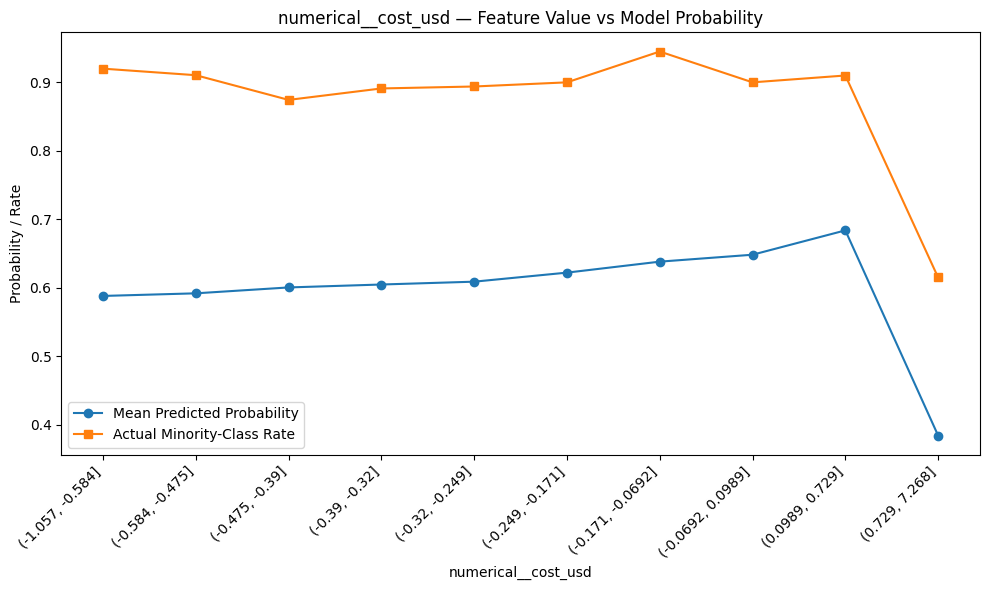

Saved: ..\reports\06_Model_Interpretation\figures\numerical__cost_usd_probability_relationship.png


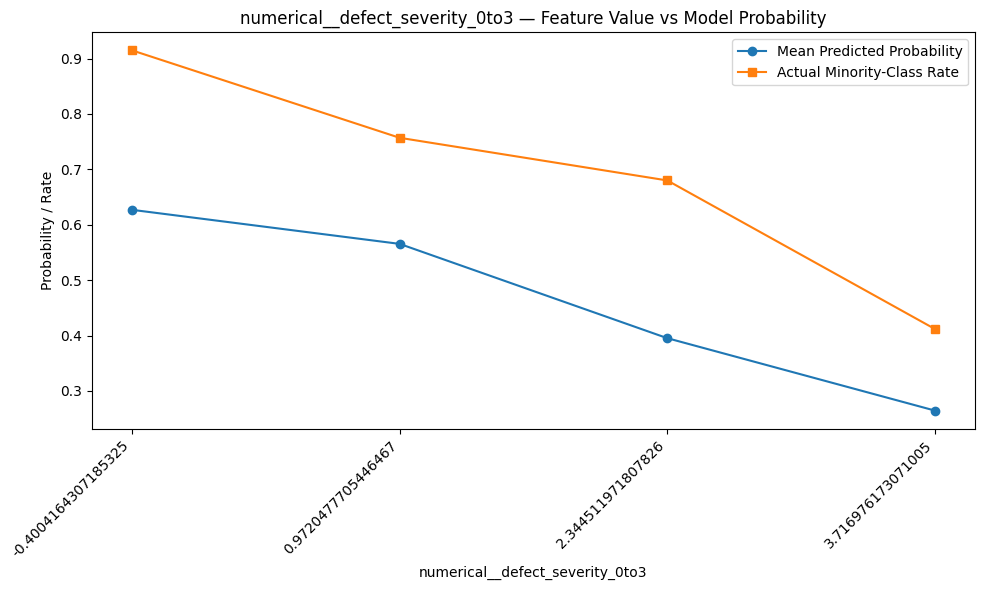

Saved: ..\reports\06_Model_Interpretation\figures\numerical__defect_severity_0to3_probability_relationship.png


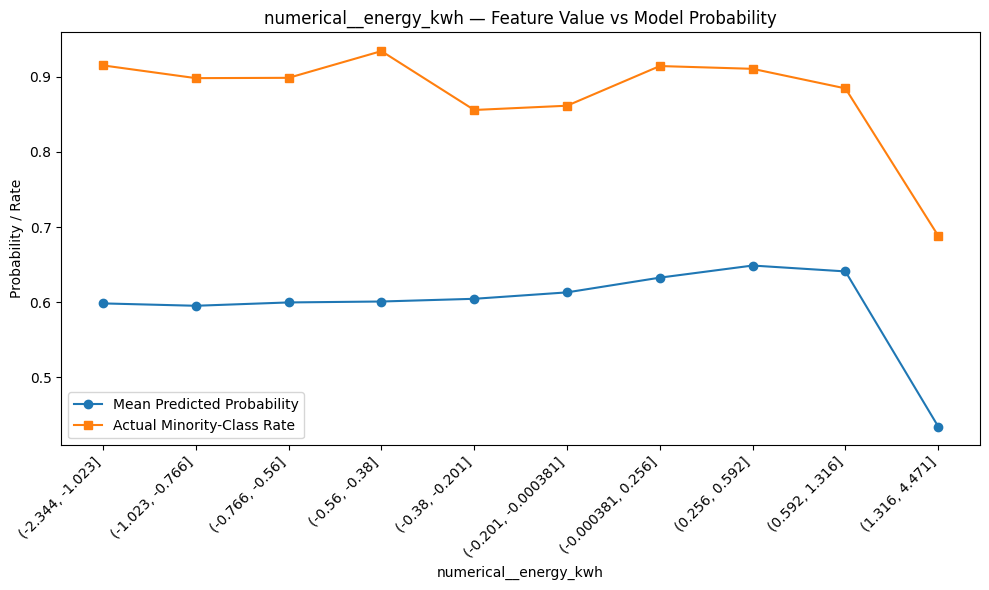

Saved: ..\reports\06_Model_Interpretation\figures\numerical__energy_kwh_probability_relationship.png


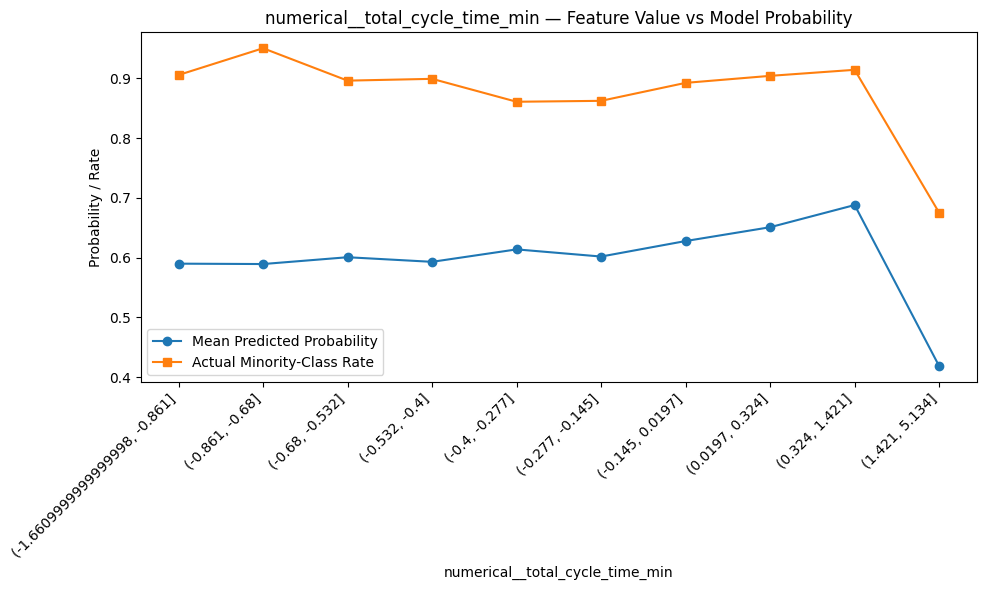

Saved: ..\reports\06_Model_Interpretation\figures\numerical__total_cycle_time_min_probability_relationship.png


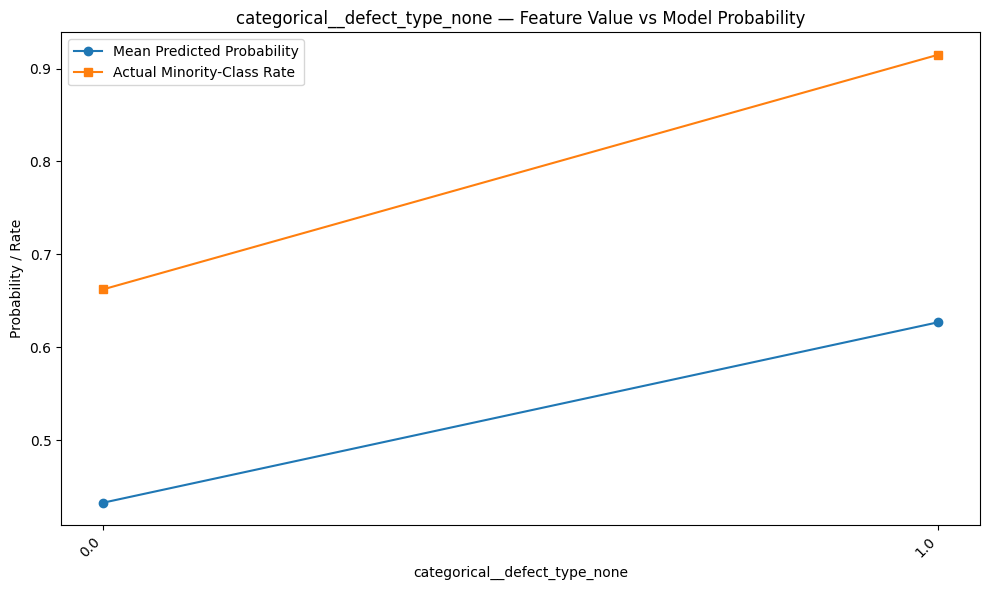

Saved: ..\reports\06_Model_Interpretation\figures\categorical__defect_type_none_probability_relationship.png


In [205]:
# ============================================================
# 10. Plot Top 5 feature relationships
# ============================================================

for feature in top_5_features:

    plot_df = feature_probability_relationships[
        feature_probability_relationships["feature"] == feature
    ].copy()

    plt.figure(figsize=(10, 6))

    x_labels = plot_df["feature_group"].astype(str)

    x_positions = np.arange(len(plot_df))

    plt.plot(
        x_positions,
        plot_df["mean_predicted_probability"],
        marker="o",
        label="Mean Predicted Probability"
    )

    plt.plot(
        x_positions,
        plot_df["actual_minority_rate"],
        marker="s",
        label="Actual Minority-Class Rate"
    )

    plt.xticks(
        x_positions,
        x_labels,
        rotation=45,
        ha="right"
    )

    plt.xlabel(feature)
    plt.ylabel("Probability / Rate")
    plt.title(
        f"{feature} — Feature Value vs Model Probability"
    )

    plt.legend()
    plt.tight_layout()

    safe_feature_name = (
        feature
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
        .replace(":", "_")
    )

    figure_path = (
        FIGURE_DIR /
        f"{safe_feature_name}_probability_relationship.png"
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", figure_path)

In [206]:
# ============================================================
# 11. Create compact relationship summary
# ============================================================

compact_relationship_summary = (
    relationship_summary_df[
        [
            "feature",
            "spearman_correlation",
            "relationship",
            "unique_values"
        ]
    ]
    .sort_values(
        "spearman_correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

compact_relationship_summary

,feature,spearman_correlation,relationship,unique_values
0,categorical__defect_type_none,0.450546,Positive relationship,2
1,numerical__total_cycle_time_min,0.084216,Weak / limited relationship,439
2,numerical__cost_usd,0.051551,Weak / limited relationship,1276
3,numerical__energy_kwh,0.026071,Weak / limited relationship,725
4,numerical__defect_severity_0to3,-0.466859,Negative relationship,4


In [207]:
# ============================================================
# 12. Section summary
# ============================================================

print("=" * 70)
print("SECTION 4 — FEATURE IMPACT & RELATIONSHIP ANALYSIS")
print("=" * 70)

for _, row in relationship_summary_df.iterrows():

    correlation = row["spearman_correlation"]

    if pd.isna(correlation):
        correlation_text = "N/A"
    else:
        correlation_text = f"{correlation:.4f}"

    print(
        f"{row['feature']}\n"
        f"  Spearman correlation : {correlation_text}\n"
        f"  Relationship         : {row['relationship']}\n"
    )

print("=" * 70)

SECTION 4 — FEATURE IMPACT & RELATIONSHIP ANALYSIS
numerical__cost_usd
  Spearman correlation : 0.0516
  Relationship         : Weak / limited relationship

numerical__defect_severity_0to3
  Spearman correlation : -0.4669
  Relationship         : Negative relationship

numerical__energy_kwh
  Spearman correlation : 0.0261
  Relationship         : Weak / limited relationship

numerical__total_cycle_time_min
  Spearman correlation : 0.0842
  Relationship         : Weak / limited relationship

categorical__defect_type_none
  Spearman correlation : 0.4505
  Relationship         : Positive relationship



## Summary & Observations

### Summary

The relationship between the most important features and the model's predicted minority-class probability was investigated using the held-out test dataset.

For each selected feature, predicted probability was compared with the actual minority-class rate across feature-value groups.

The following outputs were saved:

- `reports/06_Model_Interpretation/tables/feature_probability_relationship_summary.csv`
- `reports/06_Model_Interpretation/tables/feature_probability_relationships.csv`
- Feature-specific probability relationship figures in:
  `reports/06_Model_Interpretation/figures/`

### Observations

- The analysis shows how the model's predicted minority-class probability changes across different feature values.
- Comparing predicted probability with the actual minority-class rate provides an additional view of model behavior.
- Spearman correlation was used to summarize the direction and strength of the observed relationship.
- A positive relationship indicates that higher feature values tend to be associated with higher predicted minority-class probability.
- A negative relationship indicates the opposite pattern.
- A weak relationship indicates that the model's probability does not change consistently with the feature alone.

### Key Insight

Feature importance and feature-probability relationships provide complementary information.

Feature importance indicates **how much the model relies on a feature**, while this analysis helps investigate **how the model's predicted probability changes across different values of that feature**.

These relationships describe model behavior and should not be interpreted as causal effects.

# Section 5 — Individual Prediction Explanation
## Objective

The objective of this section is to examine individual FactoryGuard AI predictions and understand the feature characteristics associated with those predictions.

We will select representative test observations and inspect their actual class, predicted class, predicted probability, and values of the most important features.
## Why Are We Doing This?

Global feature importance explains the overall behavior of the model, but it does not show how the model behaves for a specific manufacturing observation.

Individual prediction analysis helps us:

- Understand specific correct and incorrect predictions.
- Compare predicted probability with the final decision threshold.
- Examine important feature values for individual observations.
- Understand False Positive and False Negative cases.
- Make individual model predictions easier to explain.

This analysis provides a practical case-level interpretation of the model.
## What Are We Doing?

In this section, we will:

1. Create a prediction-level dataset for the test observations.
2. Identify True Positive, True Negative, False Positive, and False Negative cases.
3. Select representative observations from each group.
4. Examine their predicted probabilities and final predictions.
5. Inspect the values of the Top 10 important features for each observation.
6. Compare individual feature values with the training-data distribution.
7. Create a summary table for the selected observations.
8. Save the individual prediction analysis for the Phase 6 report.

In [208]:
# ============================================================
# 1. Create prediction-level dataset
# ============================================================

from sklearn.metrics import confusion_matrix

# Generate probabilities and predictions
y_test_proba = final_model.predict_proba(X_test)[:, 1]

y_test_pred = (
    y_test_proba >= FINAL_THRESHOLD
).astype(int)

prediction_analysis_df = X_test.copy()

prediction_analysis_df["actual_class"] = y_test.values
prediction_analysis_df["predicted_probability"] = y_test_proba
prediction_analysis_df["predicted_class"] = y_test_pred

# Identify prediction type
def classify_prediction(row):
    
    actual = row["actual_class"]
    predicted = row["predicted_class"]
    
    if actual == 1 and predicted == 1:
        return "True Positive"
    
    elif actual == 0 and predicted == 0:
        return "True Negative"
    
    elif actual == 0 and predicted == 1:
        return "False Positive"
    
    else:
        return "False Negative"


prediction_analysis_df["prediction_type"] = (
    prediction_analysis_df.apply(
        classify_prediction,
        axis=1
    )
)

prediction_analysis_df[
    [
        "actual_class",
        "predicted_probability",
        "predicted_class",
        "prediction_type"
    ]
].head()

,actual_class,predicted_probability,predicted_class,prediction_type
0,0,0.611209,1,False Positive
1,1,0.619722,1,True Positive
2,1,0.631860,1,True Positive
3,1,0.608789,1,True Positive
4,1,0.559889,1,True Positive


In [209]:
# ============================================================
# 2. Count prediction groups
# ============================================================

prediction_group_counts = (
    prediction_analysis_df["prediction_type"]
    .value_counts()
    .reindex(
        [
            "True Positive",
            "True Negative",
            "False Positive",
            "False Negative"
        ],
        fill_value=0
    )
)

prediction_group_counts

prediction_type
True Positive     1619
True Negative       88
False Positive     160
False Negative     133
Name: count, dtype: int64

In [210]:
# ============================================================
# 3. Select representative observations
# ============================================================

prediction_analysis_df["distance_from_threshold"] = (
    abs(
        prediction_analysis_df["predicted_probability"]
        - FINAL_THRESHOLD
    )
)

selected_cases = []

prediction_types = [
    "True Positive",
    "True Negative",
    "False Positive",
    "False Negative"
]

for prediction_type in prediction_types:

    candidates = prediction_analysis_df[
        prediction_analysis_df["prediction_type"]
        == prediction_type
    ].copy()

    if len(candidates) > 0:

        selected_case = (
            candidates
            .sort_values("distance_from_threshold")
            .iloc[0]
        )

        selected_cases.append(selected_case)

selected_cases_df = pd.DataFrame(selected_cases)

selected_cases_df[
    [
        "actual_class",
        "predicted_probability",
        "predicted_class",
        "prediction_type"
    ]
]

,actual_class,predicted_probability,predicted_class,prediction_type
1781,1,0.500215,1,True Positive
1956,0,0.493607,0,True Negative
67,0,0.516375,1,False Positive
217,1,0.498959,0,False Negative


In [211]:
# ============================================================
# 4. Create test case IDs
# ============================================================

prediction_analysis_df["test_case_id"] = (
    "TEST_" +
    prediction_analysis_df.index.astype(str)
)

selected_case_ids = selected_cases_df.index

selected_cases_df["test_case_id"] = (
    "TEST_" +
    selected_cases_df.index.astype(str)
)

selected_cases_df[
    [
        "test_case_id",
        "actual_class",
        "predicted_probability",
        "predicted_class",
        "prediction_type"
    ]
]

,test_case_id,actual_class,predicted_probability,predicted_class,prediction_type
1781,TEST_1781,1,0.500215,1,True Positive
1956,TEST_1956,0,0.493607,0,True Negative
67,TEST_67,0,0.516375,1,False Positive
217,TEST_217,1,0.498959,0,False Negative


In [212]:
# ============================================================
# 5. Create individual prediction summary
# ============================================================

individual_prediction_summary = selected_cases_df[
    [
        "test_case_id",
        "actual_class",
        "predicted_probability",
        "predicted_class",
        "prediction_type",
        "distance_from_threshold"
    ]
].copy()

individual_prediction_summary[
    "threshold"
] = FINAL_THRESHOLD

individual_prediction_summary[
    "probability_margin"
] = (
    individual_prediction_summary[
        "predicted_probability"
    ]
    - FINAL_THRESHOLD
)

individual_prediction_summary

,test_case_id,actual_class,predicted_probability,predicted_class,prediction_type,distance_from_threshold,threshold,probability_margin
1781,TEST_1781,1,0.500215,1,True Positive,0.000215,0.5,0.000215
1956,TEST_1956,0,0.493607,0,True Negative,0.006393,0.5,-0.006393
67,TEST_67,0,0.516375,1,False Positive,0.016375,0.5,0.016375
217,TEST_217,1,0.498959,0,False Negative,0.001041,0.5,-0.001041


In [213]:
# ============================================================
# 6. Extract Top 10 feature values for selected cases
# ============================================================

top_10_features = (
    feature_importance_df
    .head(10)["feature"]
    .tolist()
)

case_feature_values = []

for case_index, row in selected_cases_df.iterrows():

    for rank, feature in enumerate(
        top_10_features,
        start=1
    ):

        case_feature_values.append({
            "test_case_id": row["test_case_id"],
            "prediction_type": row["prediction_type"],
            "feature_rank": rank,
            "feature": feature,
            "importance": feature_importance_df.loc[
                feature_importance_df["feature"] == feature,
                "importance"
            ].iloc[0],
            "feature_value": row[feature]
        })

case_feature_values_df = pd.DataFrame(
    case_feature_values
)

case_feature_values_df.head(20)

,test_case_id,prediction_type,feature_rank,feature,importance,feature_value
0,TEST_1781,True Positive,1,numerical__cost_usd,0.149274,-0.858162
1,TEST_1781,True Positive,2,numerical__defect_severity_0to3,0.107806,-0.400416
2,TEST_1781,True Positive,3,numerical__energy_kwh,0.073306,-1.675942
3,TEST_1781,True Positive,4,numerical__total_cycle_time_min,0.072909,-1.289645
4,TEST_1781,True Positive,5,categorical__defect_type_none,0.061021,1.000000
5,TEST_1781,True Positive,6,numerical__machine_age_yrs,0.052758,-0.282983
6,TEST_1781,True Positive,7,numerical__process_speed_units_hr,0.040828,-0.937088
7,TEST_1781,True Positive,8,numerical__humidity_pct,0.039717,1.152356
8,TEST_1781,True Positive,9,numerical__temp_c,0.038216,-0.348690
9,TEST_1781,True Positive,10,numerical__event_hour,0.028947,0.351663


In [214]:
# ============================================================
# 7. Calculate percentile position of selected feature values
# ============================================================

for feature in top_10_features:

    train_values = X_train[feature].dropna()

    if len(train_values) > 0:

        case_mask = (
            case_feature_values_df["feature"] == feature
        )

        case_feature_values_df.loc[
            case_mask,
            "training_percentile"
        ] = (
            case_feature_values_df.loc[
                case_mask,
                "feature_value"
            ]
            .apply(
                lambda value:
                (train_values <= value).mean() * 100
            )
        )

case_feature_values_df.head(20)

,test_case_id,prediction_type,feature_rank,feature,importance,feature_value,training_percentile
0,TEST_1781,True Positive,1,numerical__cost_usd,0.149274,-0.858162,0.6875
1,TEST_1781,True Positive,2,numerical__defect_severity_0to3,0.107806,-0.400416,83.8875
2,TEST_1781,True Positive,3,numerical__energy_kwh,0.073306,-1.675942,1.0375
3,TEST_1781,True Positive,4,numerical__total_cycle_time_min,0.072909,-1.289645,1.0750
4,TEST_1781,True Positive,5,categorical__defect_type_none,0.061021,1.000000,100.0000
5,TEST_1781,True Positive,6,numerical__machine_age_yrs,0.052758,-0.282983,38.9750
6,TEST_1781,True Positive,7,numerical__process_speed_units_hr,0.040828,-0.937088,17.5750
7,TEST_1781,True Positive,8,numerical__humidity_pct,0.039717,1.152356,86.2750
8,TEST_1781,True Positive,9,numerical__temp_c,0.038216,-0.348690,41.5125
9,TEST_1781,True Positive,10,numerical__event_hour,0.028947,0.351663,62.2000


In [215]:
# ============================================================
# 8. Create case-level feature table
# ============================================================

case_feature_table = case_feature_values_df.pivot(
    index="test_case_id",
    columns="feature",
    values="feature_value"
).reset_index()

case_feature_table

feature,test_case_id,categorical__defect_type_none,numerical__cost_usd,numerical__defect_severity_0to3,numerical__energy_kwh,numerical__event_hour,numerical__humidity_pct,numerical__machine_age_yrs,numerical__process_speed_units_hr,numerical__temp_c,numerical__total_cycle_time_min
0,TEST_1781,1.0,-0.858162,-0.400416,-1.675942,0.351663,1.152356,-0.282983,-0.937088,-0.348690,-1.289645
1,TEST_1956,0.0,-0.770977,0.972048,-1.801959,-0.370623,0.629269,-0.551551,-1.368290,0.337527,-1.124942
2,TEST_217,1.0,-0.539849,-0.400416,-0.527786,-0.226166,0.779854,2.457095,-0.641635,-0.097077,-0.696713
3,TEST_67,1.0,-0.263081,-0.400416,-0.406436,-1.381825,-0.416907,0.349343,-0.202449,-0.463059,-0.177897


In [216]:
# ============================================================
# 9. Display selected cases with important features
# ============================================================

for _, case in selected_cases_df.iterrows():

    print("\n" + "=" * 75)
    print(f"Case ID          : {case['test_case_id']}")
    print(f"Prediction Type  : {case['prediction_type']}")
    print(f"Actual Class     : {int(case['actual_class'])}")
    print(
        f"Predicted Class  : "
        f"{int(case['predicted_class'])}"
    )
    print(
        f"Predicted Prob.  : "
        f"{case['predicted_probability']:.4f}"
    )
    print(
        f"Decision Threshold: "
        f"{FINAL_THRESHOLD:.2f}"
    )
    print(
        f"Probability Margin: "
        f"{case['predicted_probability'] - FINAL_THRESHOLD:.4f}"
    )

    print("\nTop 10 Feature Values:")

    case_features = case_feature_values_df[
        case_feature_values_df["test_case_id"]
        == case["test_case_id"]
    ]

    display(
        case_features[
            [
                "feature_rank",
                "feature",
                "importance",
                "feature_value",
                "training_percentile"
            ]
        ]
    )


Case ID          : TEST_1781
Prediction Type  : True Positive
Actual Class     : 1
Predicted Class  : 1
Predicted Prob.  : 0.5002
Decision Threshold: 0.50
Probability Margin: 0.0002

Top 10 Feature Values:


,feature_rank,feature,importance,feature_value,training_percentile
0,1,numerical__cost_usd,0.149274,-0.858162,0.6875
1,2,numerical__defect_severity_0to3,0.107806,-0.400416,83.8875
2,3,numerical__energy_kwh,0.073306,-1.675942,1.0375
3,4,numerical__total_cycle_time_min,0.072909,-1.289645,1.0750
4,5,categorical__defect_type_none,0.061021,1.000000,100.0000
5,6,numerical__machine_age_yrs,0.052758,-0.282983,38.9750
6,7,numerical__process_speed_units_hr,0.040828,-0.937088,17.5750
7,8,numerical__humidity_pct,0.039717,1.152356,86.2750
8,9,numerical__temp_c,0.038216,-0.348690,41.5125
9,10,numerical__event_hour,0.028947,0.351663,62.2000



Case ID          : TEST_1956
Prediction Type  : True Negative
Actual Class     : 0
Predicted Class  : 0
Predicted Prob.  : 0.4936
Decision Threshold: 0.50
Probability Margin: -0.0064

Top 10 Feature Values:


,feature_rank,feature,importance,feature_value,training_percentile
10,1,numerical__cost_usd,0.149274,-0.770977,1.9250
11,2,numerical__defect_severity_0to3,0.107806,0.972048,90.0875
12,3,numerical__energy_kwh,0.073306,-1.801959,0.5875
13,4,numerical__total_cycle_time_min,0.072909,-1.124942,2.8375
14,5,categorical__defect_type_none,0.061021,0.000000,16.1125
15,6,numerical__machine_age_yrs,0.052758,-0.551551,29.6125
16,7,numerical__process_speed_units_hr,0.040828,-1.368290,8.9125
17,8,numerical__humidity_pct,0.039717,0.629269,68.9875
18,9,numerical__temp_c,0.038216,0.337527,64.9125
19,10,numerical__event_hour,0.028947,-0.370623,41.8125



Case ID          : TEST_67
Prediction Type  : False Positive
Actual Class     : 0
Predicted Class  : 1
Predicted Prob.  : 0.5164
Decision Threshold: 0.50
Probability Margin: 0.0164

Top 10 Feature Values:


,feature_rank,feature,importance,feature_value,training_percentile
20,1,numerical__cost_usd,0.149274,-0.263081,47.3625
21,2,numerical__defect_severity_0to3,0.107806,-0.400416,83.8875
22,3,numerical__energy_kwh,0.073306,-0.406436,37.3750
23,4,numerical__total_cycle_time_min,0.072909,-0.177897,56.9875
24,5,categorical__defect_type_none,0.061021,1.000000,100.0000
25,6,numerical__machine_age_yrs,0.052758,0.349343,63.3250
26,7,numerical__process_speed_units_hr,0.040828,-0.202449,43.1500
27,8,numerical__humidity_pct,0.039717,-0.416907,36.7625
28,9,numerical__temp_c,0.038216,-0.463059,37.0375
29,10,numerical__event_hour,0.028947,-1.381825,12.1500



Case ID          : TEST_217
Prediction Type  : False Negative
Actual Class     : 1
Predicted Class  : 0
Predicted Prob.  : 0.4990
Decision Threshold: 0.50
Probability Margin: -0.0010

Top 10 Feature Values:


,feature_rank,feature,importance,feature_value,training_percentile
30,1,numerical__cost_usd,0.149274,-0.539849,14.1125
31,2,numerical__defect_severity_0to3,0.107806,-0.400416,83.8875
32,3,numerical__energy_kwh,0.073306,-0.527786,30.8000
33,4,numerical__total_cycle_time_min,0.072909,-0.696713,18.6500
34,5,categorical__defect_type_none,0.061021,1.000000,100.0000
35,6,numerical__machine_age_yrs,0.052758,2.457095,99.2375
36,7,numerical__process_speed_units_hr,0.040828,-0.641635,26.2375
37,8,numerical__humidity_pct,0.039717,0.779854,74.3125
38,9,numerical__temp_c,0.038216,-0.097077,50.5875
39,10,numerical__event_hour,0.028947,-0.226166,45.6125


In [217]:
# ============================================================
# 10. Save individual prediction summary
# ============================================================

INDIVIDUAL_SUMMARY_PATH = (
    TABLE_DIR / "individual_prediction_summary.csv"
)

individual_prediction_summary.to_csv(
    INDIVIDUAL_SUMMARY_PATH,
    index=False
)

print("Saved to:")
print(INDIVIDUAL_SUMMARY_PATH)

Saved to:
..\reports\06_Model_Interpretation\tables\individual_prediction_summary.csv


In [218]:
# ============================================================
# 11. Save individual feature analysis
# ============================================================

INDIVIDUAL_FEATURE_PATH = (
    TABLE_DIR / "individual_prediction_feature_analysis.csv"
)

case_feature_values_df.to_csv(
    INDIVIDUAL_FEATURE_PATH,
    index=False
)

print("Saved to:")
print(INDIVIDUAL_FEATURE_PATH)

Saved to:
..\reports\06_Model_Interpretation\tables\individual_prediction_feature_analysis.csv


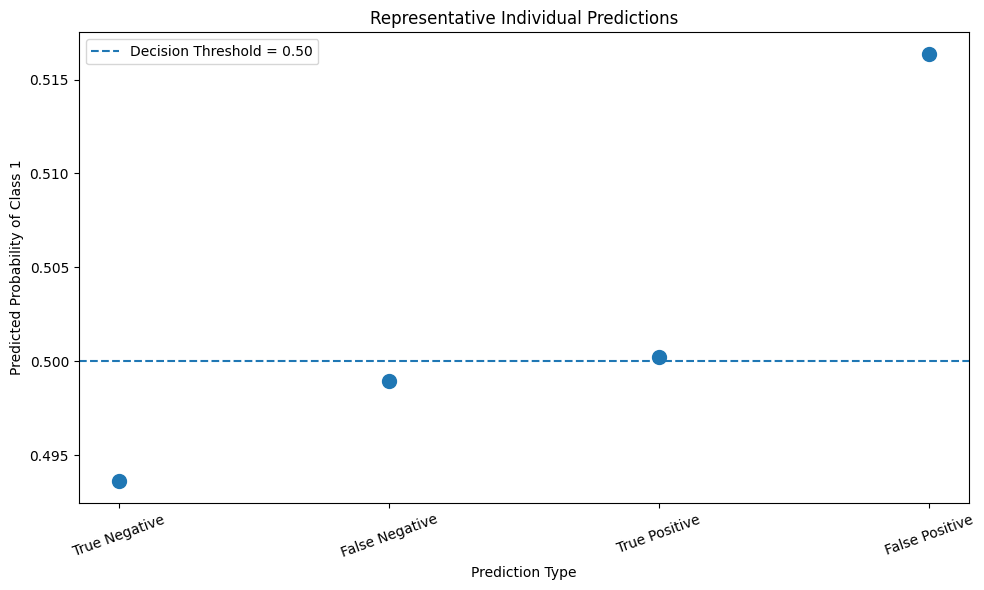

Figure saved to:
..\reports\06_Model_Interpretation\figures\individual_prediction_probabilities.png


In [219]:
# ============================================================
# 12. Plot selected prediction probabilities
# ============================================================

plot_df = individual_prediction_summary.copy()

plot_df = plot_df.sort_values(
    "predicted_probability"
)

plt.figure(figsize=(10, 6))

x_positions = np.arange(len(plot_df))

plt.scatter(
    x_positions,
    plot_df["predicted_probability"],
    s=100
)

plt.axhline(
    FINAL_THRESHOLD,
    linestyle="--",
    label=f"Decision Threshold = {FINAL_THRESHOLD:.2f}"
)

plt.xticks(
    x_positions,
    plot_df["prediction_type"],
    rotation=20
)

plt.ylabel("Predicted Probability of Class 1")
plt.xlabel("Prediction Type")
plt.title(
    "Representative Individual Predictions"
)

plt.legend()
plt.tight_layout()

INDIVIDUAL_PREDICTION_FIGURE = (
    FIGURE_DIR / "individual_prediction_probabilities.png"
)

plt.savefig(
    INDIVIDUAL_PREDICTION_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(INDIVIDUAL_PREDICTION_FIGURE)

In [220]:
# ============================================================
# 13. Section summary
# ============================================================

print("=" * 70)
print("SECTION 5 — INDIVIDUAL PREDICTION EXPLANATION")
print("=" * 70)

for _, row in individual_prediction_summary.iterrows():

    print(
        f"\n{row['test_case_id']}"
        f" → {row['prediction_type']}"
    )

    print(
        f"Actual class      : "
        f"{int(row['actual_class'])}"
    )

    print(
        f"Predicted class   : "
        f"{int(row['predicted_class'])}"
    )

    print(
        f"Probability       : "
        f"{row['predicted_probability']:.4f}"
    )

    print(
        f"Threshold         : "
        f"{FINAL_THRESHOLD:.2f}"
    )

print("\nOutputs saved successfully.")
print("=" * 70)

SECTION 5 — INDIVIDUAL PREDICTION EXPLANATION

TEST_1781 → True Positive
Actual class      : 1
Predicted class   : 1
Probability       : 0.5002
Threshold         : 0.50

TEST_1956 → True Negative
Actual class      : 0
Predicted class   : 0
Probability       : 0.4936
Threshold         : 0.50

TEST_67 → False Positive
Actual class      : 0
Predicted class   : 1
Probability       : 0.5164
Threshold         : 0.50

TEST_217 → False Negative
Actual class      : 1
Predicted class   : 0
Probability       : 0.4990
Threshold         : 0.50

Outputs saved successfully.


## Summary & Observations

### Summary

Representative observations were selected from the test set for all four prediction categories:

- True Positive
- True Negative
- False Positive
- False Negative

The selected cases were chosen based on their distance from the final decision threshold of 0.50, allowing us to examine predictions close to the model's decision boundary.

### Observations

| Case | Prediction | Probability | Interpretation |
|---|---|---:|---|
| TEST_1781 | True Positive | 0.500215 | Correctly classified as Class 1, but extremely close to the threshold |
| TEST_1956 | True Negative | 0.493607 | Correctly classified as Class 0 and close to the threshold |
| TEST_67 | False Positive | 0.516375 | Predicted Class 1, but actual class was 0 |
| TEST_217 | False Negative | 0.498959 | Predicted Class 0, but actual class was 1 |

### Key Insights

- All four representative cases have probabilities very close to the 0.50 decision threshold.
- `TEST_1781` had a probability of approximately 0.5002, resulting in a Class 1 prediction.
- `TEST_217` had a probability of approximately 0.4990, resulting in a Class 0 prediction even though its actual class was 1.
- The False Positive case (`TEST_67`) had a probability of approximately 0.5164, which was just above the threshold.
- The False Negative case (`TEST_217`) had a probability of approximately 0.4990, which was just below the threshold.
- These examples demonstrate that small changes around the decision threshold can change the final classification.

### Important Interpretation

The False Positive and False Negative examples show that some observations are difficult for the model to classify confidently.

In particular, `TEST_217` demonstrates how a minority-class observation can be missed when its predicted probability falls just below the 0.50 threshold.

This is consistent with the model's overall minority-class recall of 35.48% and highlights the importance of threshold selection and error analysis.

Individual feature values describe the characteristics of these observations, but they should not be interpreted as evidence that a single feature caused the prediction.

# Section 6 — Error Analysis & Misclassification Investigation
## Objective

The objective of this section is to analyze the model's incorrect predictions and identify patterns in False Positive and False Negative cases.

Special attention will be given to False Negatives because they represent minority-class cases that were incorrectly classified as the majority class.
## Why Are We Doing This?

Overall performance metrics tell us how well the model performs, but they do not show where the model struggles.

Error analysis helps us:

- Understand the number and proportion of False Positives and False Negatives.
- Investigate the probability distribution of incorrect predictions.
- Compare important feature values between correct and incorrect predictions.
- Identify whether False Negatives have characteristics that distinguish them from correctly detected minority cases.
- Understand the practical limitations of the final model.

Because FactoryGuard AI prioritizes minority-class detection, False Negatives are particularly important.
## What Are We Doing?

In this section, we will:

1. Separate the test observations into TP, TN, FP, and FN groups.
2. Calculate error counts and rates.
3. Analyze predicted probabilities for False Positives and False Negatives.
4. Compare False Negatives with True Positives.
5. Compare False Positives with True Negatives.
6. Analyze the Top 10 important features across prediction groups.
7. Identify features showing notable differences between correct and incorrect predictions.
8. Create visualizations of the error patterns.
9. Save the error-analysis tables and figures.

In [221]:
# ============================================================
# 1. Define minority class and generate test predictions
# ============================================================

MINORITY_CLASS = 0

# Probability of Class 1 from the Random Forest
class_1_probability = final_model.predict_proba(X_test)[:, 1]

# Probability of minority Class 0
minority_probability = 1 - class_1_probability

# Final prediction using the Phase 5 threshold
y_test_pred = (
    class_1_probability >= FINAL_THRESHOLD
).astype(int)

print("Minority class:", MINORITY_CLASS)
print("Final threshold:", FINAL_THRESHOLD)
print("Number of test observations:", len(y_test_pred))

Minority class: 0
Final threshold: 0.5
Number of test observations: 2000


In [222]:
# ============================================================
# 2. Create error analysis DataFrame
# ============================================================

error_analysis_df = X_test.copy()

error_analysis_df["actual_class"] = y_test.values
error_analysis_df["predicted_class"] = y_test_pred

# Probability of the important minority class
error_analysis_df["predicted_probability"] = minority_probability

# Distance from the 0.50 decision threshold
error_analysis_df["distance_from_threshold"] = (
    abs(
        error_analysis_df["predicted_probability"]
        - FINAL_THRESHOLD
    )
)

error_analysis_df.head()

,numerical__machine_age_yrs,numerical__temp_c,numerical__humidity_pct,numerical__process_speed_units_hr,numerical__defect_severity_0to3,numerical__decision_rework,numerical__total_cycle_time_min,numerical__energy_kwh,numerical__cost_usd,numerical__event_hour,...,categorical__material_shift_grade_B_day,categorical__material_shift_grade_B_night,categorical__material_shift_grade_B_swing,categorical__material_shift_grade_C_day,categorical__material_shift_grade_C_night,categorical__material_shift_grade_C_swing,actual_class,predicted_class,predicted_probability,distance_from_threshold
0,-0.952704,0.451897,-0.749781,0.148901,-0.400416,-0.570229,-0.383776,-1.171873,-0.374256,-1.092910,...,0.0,0.0,1.0,0.0,0.0,0.0,0,1,0.388791,0.111209
1,-1.401451,-0.234320,0.621343,-0.002818,-0.400416,-0.570229,-0.037899,0.134971,-0.187014,1.651779,...,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0.380278,0.119722
2,-0.422366,0.040167,0.676822,-0.434020,-0.400416,-0.570229,-0.367306,-0.355096,-0.363724,-0.370623,...,0.0,0.0,0.0,1.0,0.0,0.0,1,1,0.368140,0.131860
3,-1.302863,-0.280068,-1.074729,0.779733,-0.400416,-0.570229,-0.309660,0.984419,-0.330371,-0.226166,...,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0.391211,0.108789
4,1.372623,0.085914,0.835333,-0.769399,0.972048,1.753680,1.345609,1.213117,0.552596,-1.092910,...,0.0,0.0,0.0,0.0,1.0,0.0,1,1,0.440111,0.059889


In [223]:
# ============================================================
# 3. Classify predictions from minority-class perspective
# ============================================================

def classify_minority_prediction(row):

    actual = row["actual_class"]
    predicted = row["predicted_class"]

    # Actual Class 0 and predicted Class 0
    if actual == 0 and predicted == 0:
        return "True Positive"

    # Actual Class 1 and predicted Class 1
    elif actual == 1 and predicted == 1:
        return "True Negative"

    # Actual Class 1 but predicted Class 0
    elif actual == 1 and predicted == 0:
        return "False Positive"

    # Actual Class 0 but predicted Class 1
    else:
        return "False Negative"


error_analysis_df["prediction_type"] = (
    error_analysis_df.apply(
        classify_minority_prediction,
        axis=1
    )
)

prediction_counts = (
    error_analysis_df["prediction_type"]
    .value_counts()
    .reindex(
        [
            "True Positive",
            "True Negative",
            "False Positive",
            "False Negative"
        ],
        fill_value=0
    )
)

prediction_counts

prediction_type
True Positive       88
True Negative     1619
False Positive     133
False Negative     160
Name: count, dtype: int64

In [224]:
# ============================================================
# 4. Calculate minority-class error metrics
# ============================================================

tp = prediction_counts["True Positive"]
tn = prediction_counts["True Negative"]
fp = prediction_counts["False Positive"]
fn = prediction_counts["False Negative"]

minority_precision = tp / (tp + fp)
minority_recall = tp / (tp + fn)

minority_f1 = (
    2 * minority_precision * minority_recall
    / (minority_precision + minority_recall)
)

minority_fpr = fp / (fp + tn)
minority_fnr = fn / (fn + tp)

minority_error_summary = pd.DataFrame({
    "Metric": [
        "True Positives",
        "True Negatives",
        "False Positives",
        "False Negatives",
        "Minority Precision",
        "Minority Recall",
        "Minority F1",
        "False Positive Rate",
        "False Negative Rate"
    ],
    "Value": [
        tp,
        tn,
        fp,
        fn,
        minority_precision,
        minority_recall,
        minority_f1,
        minority_fpr,
        minority_fnr
    ]
})

minority_error_summary

,Metric,Value
0,True Positives,88.000000
1,True Negatives,1619.000000
2,False Positives,133.000000
3,False Negatives,160.000000
4,Minority Precision,0.398190
5,Minority Recall,0.354839
6,Minority F1,0.375267
7,False Positive Rate,0.075913
8,False Negative Rate,0.645161


In [225]:
# ============================================================
# 5. Verify against Phase 5 results
# ============================================================

print("=" * 65)
print("MINORITY CLASS (CLASS 0) — ERROR ANALYSIS")
print("=" * 65)

print(f"True Positives      : {tp}")
print(f"True Negatives      : {tn}")
print(f"False Positives     : {fp}")
print(f"False Negatives     : {fn}")

print(f"\nMinority Precision  : {minority_precision:.4f}")
print(f"Minority Recall     : {minority_recall:.4f}")
print(f"Minority F1         : {minority_f1:.4f}")
print(f"False Positive Rate : {minority_fpr:.4f}")
print(f"False Negative Rate : {minority_fnr:.4f}")

print("\nPhase 5 reference:")
print("Precision           : 0.3982")
print("Recall              : 0.3548")
print("F1                  : 0.3753")
print("False Positive Rate : 0.0759")
print("False Negative Rate : 0.6452")

print("=" * 65)

MINORITY CLASS (CLASS 0) — ERROR ANALYSIS
True Positives      : 88
True Negatives      : 1619
False Positives     : 133
False Negatives     : 160

Minority Precision  : 0.3982
Minority Recall     : 0.3548
Minority F1         : 0.3753
False Positive Rate : 0.0759
False Negative Rate : 0.6452

Phase 5 reference:
Precision           : 0.3982
Recall              : 0.3548
F1                  : 0.3753
False Positive Rate : 0.0759
False Negative Rate : 0.6452


In [226]:
# ============================================================
# 6. Analyze probabilities by prediction group
# ============================================================

probability_by_group = (
    error_analysis_df
    .groupby("prediction_type")["predicted_probability"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        minimum="min",
        maximum="max"
    )
    .reindex(
        [
            "True Positive",
            "True Negative",
            "False Positive",
            "False Negative"
        ]
    )
    .reset_index()
)

probability_by_group

,prediction_type,count,mean,median,minimum,maximum
0,True Positive,88,0.741704,0.785096,0.506393,0.925213
1,True Negative,1619,0.370955,0.380278,0.112819,0.499785
2,False Positive,133,0.583452,0.566693,0.501041,0.832652
3,False Negative,160,0.390322,0.396520,0.191270,0.483625


In [227]:
# ============================================================
# 7. Analyze probabilities of incorrect predictions
# ============================================================

error_cases = error_analysis_df[
    error_analysis_df["prediction_type"].isin(
        ["False Positive", "False Negative"]
    )
].copy()

error_probability_summary = (
    error_cases
    .groupby("prediction_type")["predicted_probability"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        minimum="min",
        maximum="max"
    )
    .reindex(
        [
            "False Positive",
            "False Negative"
        ]
    )
    .reset_index()
)

error_probability_summary

,prediction_type,count,mean,median,minimum,maximum
0,False Positive,133,0.583452,0.566693,0.501041,0.832652
1,False Negative,160,0.390322,0.396520,0.191270,0.483625


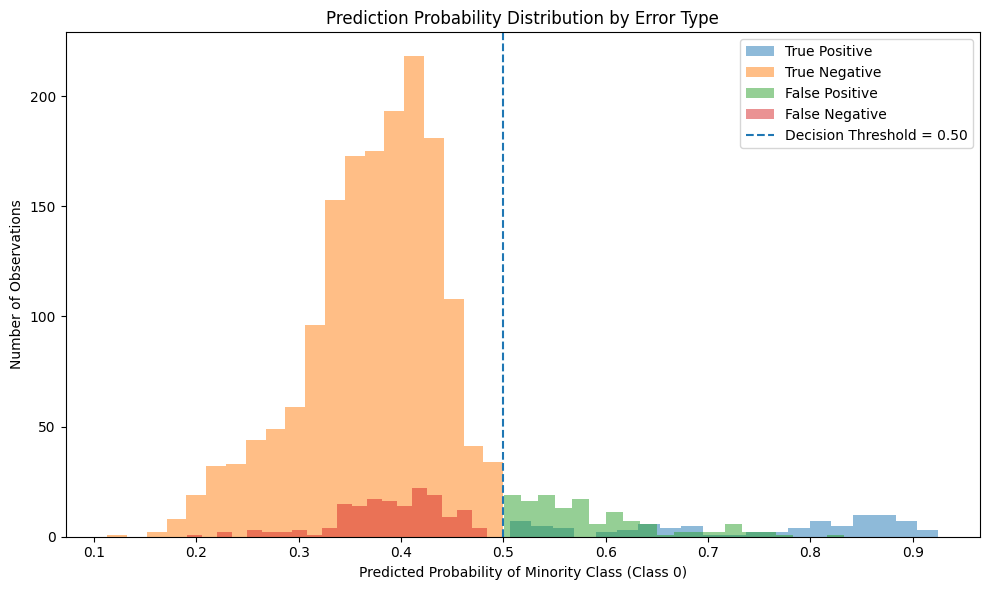

Figure saved to:
..\reports\06_Model_Interpretation\figures\prediction_probability_error_distribution.png


In [228]:
# ============================================================
# 8. Plot prediction probability distribution
# ============================================================

prediction_groups = [
    "True Positive",
    "True Negative",
    "False Positive",
    "False Negative"
]

plt.figure(figsize=(10, 6))

for group in prediction_groups:

    values = error_analysis_df.loc[
        error_analysis_df["prediction_type"] == group,
        "predicted_probability"
    ]

    if len(values) > 0:

        plt.hist(
            values,
            bins=20,
            alpha=0.5,
            label=group
        )

plt.axvline(
    FINAL_THRESHOLD,
    linestyle="--",
    label=f"Decision Threshold = {FINAL_THRESHOLD:.2f}"
)

plt.xlabel("Predicted Probability of Minority Class (Class 0)")
plt.ylabel("Number of Observations")
plt.title(
    "Prediction Probability Distribution by Error Type"
)

plt.legend()
plt.tight_layout()

ERROR_PROBABILITY_FIGURE = (
    FIGURE_DIR /
    "prediction_probability_error_distribution.png"
)

plt.savefig(
    ERROR_PROBABILITY_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(ERROR_PROBABILITY_FIGURE)

In [229]:
# ============================================================
# 9. Compare True Positives and False Negatives
# ============================================================

top_10_features = (
    feature_importance_df
    .head(10)["feature"]
    .tolist()
)

tp_fn_comparison = []

for feature in top_10_features:

    tp_values = error_analysis_df.loc[
        error_analysis_df["prediction_type"] == "True Positive",
        feature
    ]

    fn_values = error_analysis_df.loc[
        error_analysis_df["prediction_type"] == "False Negative",
        feature
    ]

    tp_mean = tp_values.mean()
    fn_mean = fn_values.mean()

    tp_fn_comparison.append({
        "feature": feature,
        "importance": feature_importance_df.loc[
            feature_importance_df["feature"] == feature,
            "importance"
        ].iloc[0],
        "true_positive_mean": tp_mean,
        "false_negative_mean": fn_mean,
        "absolute_difference": abs(
            tp_mean - fn_mean
        )
    })

tp_fn_comparison_df = (
    pd.DataFrame(tp_fn_comparison)
    .sort_values(
        "absolute_difference",
        ascending=False
    )
    .reset_index(drop=True)
)

tp_fn_comparison_df

,feature,importance,true_positive_mean,false_negative_mean,absolute_difference
0,numerical__cost_usd,0.149274,3.456734,-0.189639,3.646374
1,numerical__defect_severity_0to3,0.107806,2.516070,-0.185969,2.702039
2,numerical__total_cycle_time_min,0.072909,1.641327,-0.137339,1.778666
3,numerical__energy_kwh,0.073306,1.464568,-0.133749,1.598317
4,categorical__defect_type_none,0.061021,0.022727,0.887500,0.864773
5,numerical__process_speed_units_hr,0.040828,0.203028,-0.044915,0.247943
6,numerical__machine_age_yrs,0.052758,0.257129,0.051517,0.205612
7,numerical__humidity_pct,0.039717,-0.107720,-0.216786,0.109067
8,numerical__temp_c,0.038216,0.114247,0.066615,0.047632
9,numerical__event_hour,0.028947,-0.173636,-0.134074,0.039562


In [230]:
# ============================================================
# 10. Compare True Negatives and False Positives
# ============================================================

tn_fp_comparison = []

for feature in top_10_features:

    tn_values = error_analysis_df.loc[
        error_analysis_df["prediction_type"] == "True Negative",
        feature
    ]

    fp_values = error_analysis_df.loc[
        error_analysis_df["prediction_type"] == "False Positive",
        feature
    ]

    tn_mean = tn_values.mean()
    fp_mean = fp_values.mean()

    tn_fp_comparison.append({
        "feature": feature,
        "importance": feature_importance_df.loc[
            feature_importance_df["feature"] == feature,
            "importance"
        ].iloc[0],
        "true_negative_mean": tn_mean,
        "false_positive_mean": fp_mean,
        "absolute_difference": abs(
            tn_mean - fp_mean
        )
    })

tn_fp_comparison_df = (
    pd.DataFrame(tn_fp_comparison)
    .sort_values(
        "absolute_difference",
        ascending=False
    )
    .reset_index(drop=True)
)

tn_fp_comparison_df

,feature,importance,true_negative_mean,false_positive_mean,absolute_difference
0,numerical__defect_severity_0to3,0.107806,-0.300385,1.973018,2.273403
1,numerical__total_cycle_time_min,0.072909,-0.217105,1.468332,1.685437
2,numerical__energy_kwh,0.073306,-0.190420,1.325799,1.516219
3,numerical__cost_usd,0.149274,-0.221299,0.673102,0.894402
4,categorical__defect_type_none,0.061021,0.943175,0.157895,0.785280
5,numerical__machine_age_yrs,0.052758,-0.049374,0.491462,0.540836
6,numerical__process_speed_units_hr,0.040828,-0.008004,0.309235,0.317240
7,numerical__temp_c,0.038216,-0.009043,0.081787,0.090829
8,numerical__humidity_pct,0.039717,0.022040,-0.060733,0.082772
9,numerical__event_hour,0.028947,-0.000780,-0.040435,0.039655


In [231]:
# ============================================================
# 11. Compare Top 10 features across prediction groups
# ============================================================

group_feature_results = []

for feature in top_10_features:

    for prediction_type in prediction_groups:

        values = error_analysis_df.loc[
            error_analysis_df["prediction_type"] == prediction_type,
            feature
        ]

        group_feature_results.append({
            "feature": feature,
            "prediction_type": prediction_type,
            "mean_value": values.mean(),
            "median_value": values.median(),
            "count": len(values)
        })

group_feature_comparison = pd.DataFrame(
    group_feature_results
)

group_feature_comparison

,feature,prediction_type,mean_value,median_value,count
0,numerical__cost_usd,True Positive,3.456734,4.267317,88
1,numerical__cost_usd,True Negative,-0.221299,-0.273028,1619
2,numerical__cost_usd,False Positive,0.673102,0.913038,133
3,numerical__cost_usd,False Negative,-0.189639,-0.287364,160
4,numerical__defect_severity_0to3,True Positive,2.516070,2.344512,88
5,numerical__defect_severity_0to3,True Negative,-0.300385,-0.400416,1619
6,numerical__defect_severity_0to3,False Positive,1.973018,2.344512,133
7,numerical__defect_severity_0to3,False Negative,-0.185969,-0.400416,160
8,numerical__energy_kwh,True Positive,1.464568,1.761525,88
9,numerical__energy_kwh,True Negative,-0.190420,-0.266417,1619


In [232]:
# ============================================================
# 12. Save error summary
# ============================================================

ERROR_SUMMARY_PATH = (
    TABLE_DIR / "error_summary.csv"
)

minority_error_summary.to_csv(
    ERROR_SUMMARY_PATH,
    index=False
)

print("Saved to:")
print(ERROR_SUMMARY_PATH)

Saved to:
..\reports\06_Model_Interpretation\tables\error_summary.csv


In [233]:
# ============================================================
# 13. Save probability analysis
# ============================================================

ERROR_PROBABILITY_PATH = (
    TABLE_DIR / "error_probability_analysis.csv"
)

probability_by_group.to_csv(
    ERROR_PROBABILITY_PATH,
    index=False
)

print("Saved to:")
print(ERROR_PROBABILITY_PATH)

Saved to:
..\reports\06_Model_Interpretation\tables\error_probability_analysis.csv


In [234]:
# ============================================================
# 14. Save incorrect-prediction probability analysis
# ============================================================

ERROR_PROBABILITY_DETAIL_PATH = (
    TABLE_DIR / "incorrect_prediction_probability_analysis.csv"
)

error_probability_summary.to_csv(
    ERROR_PROBABILITY_DETAIL_PATH,
    index=False
)

print("Saved to:")
print(ERROR_PROBABILITY_DETAIL_PATH)

Saved to:
..\reports\06_Model_Interpretation\tables\incorrect_prediction_probability_analysis.csv


In [235]:
# ============================================================
# 15. Save True Positive vs False Negative analysis
# ============================================================

TP_FN_PATH = (
    TABLE_DIR / "true_positive_vs_false_negative.csv"
)

tp_fn_comparison_df.to_csv(
    TP_FN_PATH,
    index=False
)

print("Saved to:")
print(TP_FN_PATH)

Saved to:
..\reports\06_Model_Interpretation\tables\true_positive_vs_false_negative.csv


In [236]:
# ============================================================
# 16. Save True Negative vs False Positive analysis
# ============================================================

TN_FP_PATH = (
    TABLE_DIR / "true_negative_vs_false_positive.csv"
)

tn_fp_comparison_df.to_csv(
    TN_FP_PATH,
    index=False
)

print("Saved to:")
print(TN_FP_PATH)

Saved to:
..\reports\06_Model_Interpretation\tables\true_negative_vs_false_positive.csv


In [237]:
# ============================================================
# 17. Save prediction-group feature comparison
# ============================================================

GROUP_FEATURE_PATH = (
    TABLE_DIR / "prediction_group_feature_comparison.csv"
)

group_feature_comparison.to_csv(
    GROUP_FEATURE_PATH,
    index=False
)

print("Saved to:")
print(GROUP_FEATURE_PATH)

Saved to:
..\reports\06_Model_Interpretation\tables\prediction_group_feature_comparison.csv


In [238]:
# ============================================================
# 18. Final Section Summary
# ============================================================

print("=" * 70)
print("SECTION 6 — ERROR ANALYSIS & MISCLASSIFICATION")
print("=" * 70)

print("\nPrediction counts:")
print(prediction_counts)

print("\nMinority-class metrics:")
print(
    f"Precision           : {minority_precision:.4f}"
)
print(
    f"Recall              : {minority_recall:.4f}"
)
print(
    f"F1-score            : {minority_f1:.4f}"
)
print(
    f"False Positive Rate : {minority_fpr:.4f}"
)
print(
    f"False Negative Rate : {minority_fnr:.4f}"
)

print("\nFalse Negative cases:", fn)
print("False Positive cases:", fp)

print("\nOutputs saved successfully.")

print("=" * 70)

SECTION 6 — ERROR ANALYSIS & MISCLASSIFICATION

Prediction counts:
prediction_type
True Positive       88
True Negative     1619
False Positive     133
False Negative     160
Name: count, dtype: int64

Minority-class metrics:
Precision           : 0.3982
Recall              : 0.3548
F1-score            : 0.3753
False Positive Rate : 0.0759
False Negative Rate : 0.6452

False Negative cases: 160
False Positive cases: 133

Outputs saved successfully.


## Summary & Observations

### Summary

The final Random Forest model was analyzed from the perspective of the minority Class 0.

The test set produced:

- True Positives: 88
- True Negatives: 1,619
- False Positives: 133
- False Negatives: 160

The resulting minority-class metrics remain consistent with Phase 5:

- Minority Precision: 39.82%
- Minority Recall: 35.48%
- Minority F1-score: 37.53%
- False Positive Rate: 7.59%
- False Negative Rate: 64.52%

### Observations

- The model correctly detected 88 of the 248 minority-class observations.
- 160 minority-class observations were incorrectly classified as Class 1, resulting in a high False Negative Rate of 64.52%.
- True Positive cases had a substantially higher mean minority-class probability (0.7417) than False Negative cases (0.3903).
- False Positive cases had a higher mean minority-class probability (0.5835) than True Negative cases (0.3710), showing that some majority-class observations appear similar to minority cases from the model's perspective.
- The largest differences between True Positive and False Negative cases were observed in processed `cost_usd`, `defect_severity_0to3`, `total_cycle_time_min`, and `energy_kwh` features.
- The `categorical__defect_type_none` feature also showed a notable difference between True Positive and False Negative groups.

### Key Insights

The error analysis shows that the model does not fail randomly. The minority cases that are missed by the model have different feature profiles from the minority cases that are successfully detected.

The large difference between True Positive and False Negative groups suggests that certain manufacturing patterns are easier for the model to identify than others.

However, the feature differences are based on processed feature values and should not be interpreted as causal relationships.

The high False Negative Rate confirms that FactoryGuard AI should be positioned as a **decision-support system for identifying potentially problematic cases**, rather than as a fully automated quality-control system.

# Section 7 — Business Interpretation & Model Limitations
## Objective

The objective of this section is to translate the model's technical results into practical manufacturing and business insights.

We will summarize what the final model can identify, where it performs well, where it struggles, and how the system should be used in a real-world decision-support setting.
## Why Are We Doing This?

Machine-learning performance metrics alone do not explain the practical value or limitations of a model.

FactoryGuard AI is intended to support manufacturing decision-making, so its predictions need to be interpreted in terms of:

- Potentially problematic manufacturing cases.
- Correctly identified minority-class cases.
- Missed minority-class cases.
- False alarms.
- Human investigation requirements.
- Limitations of the available data and model.

Clearly documenting these factors prevents overclaiming the capabilities of the system.
## What Are We Doing?

In this section, we will:

1. Summarize the final model performance.
2. Interpret the model's strengths from a business perspective.
3. Interpret the model's weaknesses and error patterns.
4. Explain the practical meaning of False Positives and False Negatives.
5. Define the appropriate role of FactoryGuard AI in a manufacturing workflow.
6. Document important model and dataset limitations.
7. Define potential future improvements.
8. Create a consolidated business interpretation and limitations report.

In [239]:
# ============================================================
# 1. Define final model performance
# ============================================================

final_model_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Minority Precision",
        "Minority Recall",
        "Minority F1-score",
        "ROC-AUC",
        "PR-AUC",
        "False Positive Rate",
        "False Negative Rate"
    ],
    "Value": [
        0.8535,
        0.3982,
        0.3548,
        0.3753,
        0.7009,
        0.4244,
        0.0759,
        0.6452
    ]
})

final_model_metrics

,Metric,Value
0,Accuracy,0.8535
1,Minority Precision,0.3982
2,Minority Recall,0.3548
3,Minority F1-score,0.3753
4,ROC-AUC,0.7009
5,PR-AUC,0.4244
6,False Positive Rate,0.0759
7,False Negative Rate,0.6452


In [240]:
# ============================================================
# 2. Create percentage representation
# ============================================================

final_model_metrics["Percentage"] = (
    final_model_metrics["Value"] * 100
)

final_model_metrics

,Metric,Value,Percentage
0,Accuracy,0.8535,85.35
1,Minority Precision,0.3982,39.82
2,Minority Recall,0.3548,35.48
3,Minority F1-score,0.3753,37.53
4,ROC-AUC,0.7009,70.09
5,PR-AUC,0.4244,42.44
6,False Positive Rate,0.0759,7.59
7,False Negative Rate,0.6452,64.52


In [241]:
# ============================================================
# 3. Create business interpretation table
# ============================================================

business_interpretation = pd.DataFrame({
    "Aspect": [
        "Overall accuracy",
        "Minority-class detection",
        "Minority precision",
        "ROC-AUC",
        "False positives",
        "False negatives",
        "Recommended system role"
    ],
    "Interpretation": [
        "The model correctly classifies approximately 85% of test observations.",
        
        "The model detects approximately 35% of actual minority-class cases.",
        
        "Approximately 40% of cases predicted as the minority class are actually minority-class cases.",
        
        "The model demonstrates meaningful ability to distinguish between the two classes.",
        
        "Some majority-class cases are incorrectly flagged as minority cases and may require unnecessary investigation.",
        
        "A substantial number of actual minority-class cases are missed by the model.",
        
        "Use as a decision-support and screening system rather than a fully automated quality-control system."
    ]
})

business_interpretation

,Aspect,Interpretation
0,Overall accuracy,The model correctly classifies approximately 8...
1,Minority-class detection,The model detects approximately 35% of actual ...
2,Minority precision,Approximately 40% of cases predicted as the mi...
3,ROC-AUC,The model demonstrates meaningful ability to d...
4,False positives,Some majority-class cases are incorrectly flag...
5,False negatives,A substantial number of actual minority-class ...
6,Recommended system role,Use as a decision-support and screening system...


In [242]:
# ============================================================
# 4. Create error interpretation table
# ============================================================

error_business_interpretation = pd.DataFrame({
    "Prediction Type": [
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative"
    ],
    "Technical Meaning": [
        "Actual Class 0 and predicted Class 0.",
        "Actual Class 1 and predicted Class 1.",
        "Actual Class 1 but predicted Class 0.",
        "Actual Class 0 but predicted Class 1."
    ],
    "Business Interpretation": [
        "Potentially problematic case correctly flagged for investigation.",
        "Normal/majority case correctly classified.",
        "A normal case is incorrectly flagged and may receive unnecessary investigation.",
        "A potentially problematic case is missed by the model."
    ],
    "Priority": [
        "Desired detection",
        "Desired outcome",
        "False alarm",
        "Critical miss"
    ]
})

error_business_interpretation

,Prediction Type,Technical Meaning,Business Interpretation,Priority
0,True Positive,Actual Class 0 and predicted Class 0.,Potentially problematic case correctly flagged...,Desired detection
1,True Negative,Actual Class 1 and predicted Class 1.,Normal/majority case correctly classified.,Desired outcome
2,False Positive,Actual Class 1 but predicted Class 0.,A normal case is incorrectly flagged and may r...,False alarm
3,False Negative,Actual Class 0 but predicted Class 1.,A potentially problematic case is missed by th...,Critical miss


In [243]:
# ============================================================
# 5. Model strengths
# ============================================================

model_strengths = pd.DataFrame({
    "Strength": [
        "Meaningful class separation",
        "Reasonable overall accuracy",
        "Low false-positive rate",
        "Nonlinear pattern detection",
        "Feature-level interpretability"
    ],
    "Evidence": [
        "ROC-AUC = 0.7009",
        "Accuracy = 85.35%",
        "False Positive Rate = 7.59%",
        "Random Forest can capture nonlinear relationships in tabular manufacturing data.",
        "Feature importance and error analysis identify influential variables."
    ]
})

model_strengths

,Strength,Evidence
0,Meaningful class separation,ROC-AUC = 0.7009
1,Reasonable overall accuracy,Accuracy = 85.35%
2,Low false-positive rate,False Positive Rate = 7.59%
3,Nonlinear pattern detection,Random Forest can capture nonlinear relationsh...
4,Feature-level interpretability,Feature importance and error analysis identify...


In [244]:
# ============================================================
# 6. Model limitations
# ============================================================

model_limitations = pd.DataFrame({
    "Limitation": [
        "Low minority-class recall",
        "High false-negative rate",
        "Moderate minority F1-score",
        "Class imbalance",
        "Dataset dependence",
        "Feature dependence",
        "Potential distribution shift",
        "No causal interpretation"
    ],
    "Evidence": [
        "Minority recall = 35.48%",
        "False Negative Rate = 64.52%",
        "Minority F1 = 37.53%",
        "Class 0 represents approximately 12.39% of observations.",
        "Performance depends on the quality and representativeness of the available dataset.",
        "Predictions depend on the features available during training and inference.",
        "Real-world manufacturing conditions may differ from the training data.",
        "Feature importance and associations do not establish causal relationships."
    ]
})

model_limitations

,Limitation,Evidence
0,Low minority-class recall,Minority recall = 35.48%
1,High false-negative rate,False Negative Rate = 64.52%
2,Moderate minority F1-score,Minority F1 = 37.53%
3,Class imbalance,Class 0 represents approximately 12.39% of obs...
4,Dataset dependence,Performance depends on the quality and represe...
5,Feature dependence,Predictions depend on the features available d...
6,Potential distribution shift,Real-world manufacturing conditions may differ...
7,No causal interpretation,Feature importance and associations do not est...


In [245]:
# ============================================================
# 7. Recommended FactoryGuard AI workflow
# ============================================================

factoryguard_workflow = pd.DataFrame({
    "Step": [
        1,
        2,
        3,
        4,
        5,
        6
    ],
    "Process": [
        "Manufacturing data is collected",
        "Data is processed using the saved preprocessing pipeline",
        "Random Forest generates a minority-class probability",
        "Probability is compared with the 0.50 decision threshold",
        "Potentially problematic cases are flagged",
        "Human/operator reviews flagged cases and takes appropriate action"
    ]
})

factoryguard_workflow

,Step,Process
0,1,Manufacturing data is collected
1,2,Data is processed using the saved preprocessin...
2,3,Random Forest generates a minority-class proba...
3,4,Probability is compared with the 0.50 decision...
4,5,Potentially problematic cases are flagged
5,6,Human/operator reviews flagged cases and takes...


In [246]:
# ============================================================
# 8. Potential future improvements
# ============================================================

future_improvements = pd.DataFrame({
    "Area": [
        "Data collection",
        "Class imbalance",
        "Threshold optimization",
        "Modeling",
        "Explainability",
        "Monitoring"
    ],
    "Potential Improvement": [
        "Collect more representative minority-class observations.",
        "Evaluate additional imbalance-handling techniques.",
        "Optimize the threshold according to the actual business cost of false negatives and false positives.",
        "Evaluate additional models and ensemble strategies.",
        "Introduce more detailed local explanations when required.",
        "Monitor model performance and data distribution after deployment."
    ]
})

future_improvements

,Area,Potential Improvement
0,Data collection,Collect more representative minority-class obs...
1,Class imbalance,Evaluate additional imbalance-handling techniq...
2,Threshold optimization,Optimize the threshold according to the actual...
3,Modeling,Evaluate additional models and ensemble strate...
4,Explainability,Introduce more detailed local explanations whe...
5,Monitoring,Monitor model performance and data distributio...


In [247]:
# ============================================================
# 9. Save final model metrics
# ============================================================

BUSINESS_TABLE_DIR = TABLE_DIR

final_model_metrics.to_csv(
    BUSINESS_TABLE_DIR / "final_model_metrics.csv",
    index=False
)

print("Saved final model metrics.")

Saved final model metrics.


In [248]:
# ============================================================
# 10. Save business interpretation
# ============================================================

business_interpretation.to_csv(
    BUSINESS_TABLE_DIR / "business_interpretation.csv",
    index=False
)

error_business_interpretation.to_csv(
    BUSINESS_TABLE_DIR / "error_business_interpretation.csv",
    index=False
)

print("Saved business interpretation tables.")

Saved business interpretation tables.


In [249]:
# ============================================================
# 11. Save strengths and limitations
# ============================================================

model_strengths.to_csv(
    BUSINESS_TABLE_DIR / "model_strengths.csv",
    index=False
)

model_limitations.to_csv(
    BUSINESS_TABLE_DIR / "model_limitations.csv",
    index=False
)

print("Saved model strengths and limitations.")

Saved model strengths and limitations.


In [250]:
# ============================================================
# 12. Save workflow and future improvements
# ============================================================

factoryguard_workflow.to_csv(
    BUSINESS_TABLE_DIR / "factoryguard_workflow.csv",
    index=False
)

future_improvements.to_csv(
    BUSINESS_TABLE_DIR / "future_improvements.csv",
    index=False
)

print("Saved workflow and future improvement tables.")

Saved workflow and future improvement tables.


In [251]:
# ============================================================
# 13. Create business interpretation report
# ============================================================

business_report = f"""# FactoryGuard AI — Business Interpretation & Model Limitations

## Final Model

- Model: Random Forest Classifier
- Decision Threshold: 0.50
- Training Records: 8,000
- Test Records: 2,000

## Final Test Performance

- Accuracy: 85.35%
- Minority Precision: 39.82%
- Minority Recall: 35.48%
- Minority F1-score: 37.53%
- ROC-AUC: 70.09%
- PR-AUC: 42.44%
- False Positive Rate: 7.59%
- False Negative Rate: 64.52%

## Business Interpretation

FactoryGuard AI is designed as a decision-support system for identifying potentially problematic manufacturing outcomes.

The model demonstrates meaningful predictive capability, with a ROC-AUC of approximately 0.70 and an overall accuracy of approximately 85%.

However, minority-class recall is only 35.48%. This means that a substantial proportion of minority-class cases are not detected.

Therefore, the model should be used as a screening and decision-support tool rather than as a fully automated quality-control system.

## False Positive

A False Positive occurs when a majority-class case is incorrectly flagged as a minority-class case.

Business implication:

The case may receive unnecessary investigation or additional quality-control attention.

## False Negative

A False Negative occurs when an actual minority-class case is incorrectly classified as the majority class.

Business implication:

A potentially problematic case may be missed by the system.

Because False Negatives are more important for the project's detection objective, they should receive particular attention when evaluating future model improvements.

## Model Strengths

- Meaningful class-separation capability.
- Good overall accuracy.
- Relatively low false-positive rate.
- Ability to capture nonlinear relationships in structured manufacturing data.
- Global feature importance provides model interpretability.

## Model Limitations

- Minority-class recall is limited.
- False-negative rate is high.
- The target variable is imbalanced.
- Model performance depends on the quality and representativeness of the training data.
- Real-world manufacturing conditions may differ from the training data.
- Predictions depend on the features available during inference.
- Feature relationships should not be interpreted as causal relationships.

## Recommended Operational Role

FactoryGuard AI should operate as:

Manufacturing Data
→ Preprocessing
→ Random Forest Prediction
→ Minority-Class Probability
→ Threshold-Based Flag
→ Human Review
→ Appropriate Manufacturing Action

The model should support human decision-making rather than replace human quality-control judgment.

## Potential Future Improvements

- Collect more representative minority-class data.
- Evaluate additional imbalance-handling strategies.
- Optimize the threshold according to business costs.
- Evaluate additional classification models.
- Improve local prediction explanations.
- Monitor model performance and data drift after deployment.
"""

BUSINESS_REPORT_PATH = (
    PHASE6_REPORT_DIR /
    "business_interpretation_and_limitations.md"
)

BUSINESS_REPORT_PATH.write_text(
    business_report,
    encoding="utf-8"
)

print("Business interpretation report saved to:")
print(BUSINESS_REPORT_PATH)

Business interpretation report saved to:
..\reports\06_Model_Interpretation\business_interpretation_and_limitations.md


In [252]:
# ============================================================
# 14. Section summary
# ============================================================

print("=" * 70)
print("SECTION 7 — BUSINESS INTERPRETATION & MODEL LIMITATIONS")
print("=" * 70)

print("\nFinal Model:")
print("Random Forest Classifier")
print("Decision Threshold:", FINAL_THRESHOLD)

print("\nKey Performance:")
print(f"Accuracy           : {0.8535:.4f}")
print(f"Minority Precision : {0.3982:.4f}")
print(f"Minority Recall    : {0.3548:.4f}")
print(f"Minority F1        : {0.3753:.4f}")
print(f"ROC-AUC            : {0.7009:.4f}")
print(f"PR-AUC             : {0.4244:.4f}")

print("\nMost Important Limitation:")
print("High minority-class False Negative Rate = 64.52%")

print("\nRecommended Role:")
print("Decision-support and screening system")

print("\nBusiness interpretation report saved successfully.")

print("=" * 70)

SECTION 7 — BUSINESS INTERPRETATION & MODEL LIMITATIONS

Final Model:
Random Forest Classifier
Decision Threshold: 0.5

Key Performance:
Accuracy           : 0.8535
Minority Precision : 0.3982
Minority Recall    : 0.3548
Minority F1        : 0.3753
ROC-AUC            : 0.7009
PR-AUC             : 0.4244

Most Important Limitation:
High minority-class False Negative Rate = 64.52%

Recommended Role:
Decision-support and screening system

Business interpretation report saved successfully.


## Summary & Observations

### Summary

The technical results from Phase 5 and the explainability analyses were translated into business-level interpretations.

The final Random Forest provides useful predictive capability, but its minority-class recall is limited.

### Observations

- The model achieves 85.35% overall accuracy.
- ROC-AUC of 0.7009 indicates meaningful class-separation capability.
- Minority-class precision is 39.82%.
- Minority-class recall is 35.48%.
- The False Negative Rate is 64.52%, making missed minority-class cases the primary limitation.
- The False Positive Rate is relatively low at 7.59%.
- The model can identify useful patterns in the structured manufacturing data but does not detect all minority-class cases.

### Business Interpretation

FactoryGuard AI should be positioned as a **decision-support and screening system**.

Its purpose is to flag potentially problematic manufacturing cases for further investigation rather than automatically making final quality-control decisions.

A False Positive may result in unnecessary investigation, while a False Negative may allow a potentially problematic case to go unnoticed.

### Model Limitations

The main limitations are:

- Limited minority-class recall.
- High False Negative Rate.
- Class imbalance.
- Dependence on available features and training data.
- Possible differences between historical training data and future manufacturing conditions.
- Feature importance does not imply causation.

### Future Improvements

Potential improvements include collecting more minority-class examples, evaluating additional imbalance-handling techniques, optimizing the threshold according to business costs, evaluating additional models, and monitoring model performance after deployment.

The detailed business interpretation was saved to:

`reports/06_Model_Interpretation/business_interpretation_and_limitations.md`

# Section 8 — Phase 6 Summary & Documentation
## Objective

The objective of this section is to consolidate the model interpretation and explainability analysis performed throughout Phase 6.

The final documentation will summarize:

- Global feature importance.
- Feature-level relationships.
- Individual prediction analysis.
- Error and misclassification analysis.
- Business interpretation.
- Model strengths and limitations.
- Recommended future improvements.

The resulting documentation will provide a clear explanation of how the final FactoryGuard AI model behaves and how its predictions should be interpreted.
## Why Are We Doing This?

A machine-learning project should document not only model performance but also how the model behaves and where it can fail.

The Phase 6 documentation provides a consolidated reference for:

- Understanding the final model.
- Explaining important features.
- Understanding individual predictions.
- Understanding False Positives and False Negatives.
- Communicating model limitations.
- Supporting future deployment and monitoring.
- Preparing the project for technical and business discussions.
## What Are We Doing?

In this section, we will:

1. Consolidate the major findings from Phase 6.
2. Record the final model configuration.
3. Summarize the most important features.
4. Summarize the error-analysis findings.
5. Document the business interpretation.
6. Document model limitations.
7. Record recommended future improvements.
8. Generate a final Phase 6 Markdown report.
9. Verify that the major Phase 6 outputs have been created.

In [253]:
# ============================================================
# 1. Define Phase 6 configuration
# ============================================================

phase6_summary = {
    "phase": "Phase 6 — Model Interpretation & Explainability",
    "model": "Random Forest Classifier",
    "decision_threshold": FINAL_THRESHOLD,
    "minority_class": 0,
    "majority_class": 1,
    "training_records": len(X_train),
    "test_records": len(X_test)
}

phase6_summary

{'phase': 'Phase 6 — Model Interpretation & Explainability',
 'model': 'Random Forest Classifier',
 'decision_threshold': 0.5,
 'minority_class': 0,
 'majority_class': 1,
 'training_records': 8000,
 'test_records': 2000}

In [254]:
# ============================================================
# 2. Final model performance summary
# ============================================================

phase6_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Minority Precision",
        "Minority Recall",
        "Minority F1-score",
        "ROC-AUC",
        "PR-AUC",
        "False Positive Rate",
        "False Negative Rate"
    ],
    "Value": [
        0.8535,
        0.3982,
        0.3548,
        0.3753,
        0.7009,
        0.4244,
        0.0759,
        0.6452
    ]
})

phase6_metrics

,Metric,Value
0,Accuracy,0.8535
1,Minority Precision,0.3982
2,Minority Recall,0.3548
3,Minority F1-score,0.3753
4,ROC-AUC,0.7009
5,PR-AUC,0.4244
6,False Positive Rate,0.0759
7,False Negative Rate,0.6452


In [255]:
# ============================================================
# 3. Error analysis summary
# ============================================================

phase6_error_summary = pd.DataFrame({
    "Prediction Type": [
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative"
    ],
    "Count": [
        tp,
        tn,
        fp,
        fn
    ],
    "Interpretation": [
        "Minority-class cases correctly detected.",
        "Majority-class cases correctly classified.",
        "Majority-class cases incorrectly flagged as minority.",
        "Minority-class cases incorrectly classified as majority."
    ]
})

phase6_error_summary

,Prediction Type,Count,Interpretation
0,True Positive,88,Minority-class cases correctly detected.
1,True Negative,1619,Majority-class cases correctly classified.
2,False Positive,133,Majority-class cases incorrectly flagged as mi...
3,False Negative,160,Minority-class cases incorrectly classified as...


In [256]:
# ============================================================
# 4. Feature importance summary
# ============================================================

phase6_top_features = (
    feature_importance_df
    .head(10)
    .copy()
)

phase6_top_features

,rank,feature,importance
0,1,numerical__cost_usd,0.149274
1,2,numerical__defect_severity_0to3,0.107806
2,3,numerical__energy_kwh,0.073306
3,4,numerical__total_cycle_time_min,0.072909
4,5,categorical__defect_type_none,0.061021
5,6,numerical__machine_age_yrs,0.052758
6,7,numerical__process_speed_units_hr,0.040828
7,8,numerical__humidity_pct,0.039717
8,9,numerical__temp_c,0.038216
9,10,numerical__event_hour,0.028947


In [257]:
# ============================================================
# 5. Extract top feature names
# ============================================================

top_feature_names = (
    phase6_top_features["feature"]
    .tolist()
)

print("Top 10 important features:")
for rank, feature in enumerate(
    top_feature_names,
    start=1
):
    print(f"{rank}. {feature}")

Top 10 important features:
1. numerical__cost_usd
2. numerical__defect_severity_0to3
3. numerical__energy_kwh
4. numerical__total_cycle_time_min
5. categorical__defect_type_none
6. numerical__machine_age_yrs
7. numerical__process_speed_units_hr
8. numerical__humidity_pct
9. numerical__temp_c
10. numerical__event_hour


In [258]:
# ============================================================
# 6. Create explainability findings
# ============================================================

explainability_findings = pd.DataFrame({
    "Finding": [
        "Global feature importance",
        "Individual prediction analysis",
        "Prediction probability analysis",
        "False Negative analysis",
        "False Positive analysis",
        "Business interpretation"
    ],
    "Finding Summary": [
        "Feature importance identifies the variables contributing most strongly to the Random Forest's predictions.",
        "Representative TP, TN, FP and FN observations were examined at the individual level.",
        "Prediction probabilities show how observations are distributed around the 0.50 decision threshold.",
        "False Negatives represent missed minority-class cases and are the primary model limitation.",
        "False Positives represent majority-class cases incorrectly flagged as minority cases.",
        "The model is best positioned as a decision-support and screening system."
    ]
})

explainability_findings

,Finding,Finding Summary
0,Global feature importance,Feature importance identifies the variables co...
1,Individual prediction analysis,"Representative TP, TN, FP and FN observations ..."
2,Prediction probability analysis,Prediction probabilities show how observations...
3,False Negative analysis,False Negatives represent missed minority-clas...
4,False Positive analysis,False Positives represent majority-class cases...
5,Business interpretation,The model is best positioned as a decision-sup...


In [259]:
# ============================================================
# 7. Phase 6 limitations
# ============================================================

phase6_limitations = pd.DataFrame({
    "Limitation": [
        "Minority-class recall",
        "False-negative rate",
        "Class imbalance",
        "Dataset dependence",
        "Processed feature interpretation",
        "No causal interpretation",
        "Potential data distribution shift"
    ],
    "Description": [
        "The model detects only 35.48% of actual minority-class observations.",
        "64.52% of actual minority-class observations are missed.",
        "The minority class represents approximately 12.39% of the dataset.",
        "Model behavior depends on the quality and representativeness of the available data.",
        "Some features are encoded or scaled, so processed values should not be interpreted directly as original business units.",
        "Feature importance indicates predictive association rather than causation.",
        "Future manufacturing data may differ from the historical training distribution."
    ]
})

phase6_limitations

,Limitation,Description
0,Minority-class recall,The model detects only 35.48% of actual minori...
1,False-negative rate,64.52% of actual minority-class observations a...
2,Class imbalance,The minority class represents approximately 12...
3,Dataset dependence,Model behavior depends on the quality and repr...
4,Processed feature interpretation,"Some features are encoded or scaled, so proces..."
5,No causal interpretation,Feature importance indicates predictive associ...
6,Potential data distribution shift,Future manufacturing data may differ from the ...


In [260]:
# ============================================================
# 8. Future improvement summary
# ============================================================

phase6_future_work = pd.DataFrame({
    "Priority": [
        "High",
        "High",
        "Medium",
        "Medium",
        "Medium",
        "Medium"
    ],
    "Improvement": [
        "Collect more representative minority-class observations.",
        "Evaluate additional class-imbalance handling techniques.",
        "Optimize the classification threshold according to actual business costs.",
        "Evaluate additional classification models and ensemble strategies.",
        "Improve local prediction explanations where required.",
        "Monitor model performance and data distribution after deployment."
    ]
})

phase6_future_work

,Priority,Improvement
0,High,Collect more representative minority-class obs...
1,High,Evaluate additional class-imbalance handling t...
2,Medium,Optimize the classification threshold accordin...
3,Medium,Evaluate additional classification models and ...
4,Medium,Improve local prediction explanations where re...
5,Medium,Monitor model performance and data distributio...


# ============================================================
# 9. Save Phase 6 summary tables
# ============================================================

phase6_metrics.to_csv(
    TABLE_DIR / "phase6_final_metrics.csv",
    index=False
)

phase6_error_summary.to_csv(
    TABLE_DIR / "phase6_error_summary.csv",
    index=False
)

phase6_top_features.to_csv(
    TABLE_DIR / "phase6_top_features.csv",
    index=False
)

explainability_findings.to_csv(
    TABLE_DIR / "phase6_explainability_findings.csv",
    index=False
)

phase6_limitations.to_csv(
    TABLE_DIR / "phase6_limitations.csv",
    index=False
)

phase6_future_work.to_csv(
    TABLE_DIR / "phase6_future_work.csv",
    index=False
)

print("Phase 6 summary tables saved successfully.")

In [261]:
# ============================================================
# 10. Verify Phase 6 output files
# ============================================================

expected_phase6_files = [
    FIGURE_DIR / "top_15_feature_importance.png",
    FIGURE_DIR / "top_5_feature_distributions.png",
    FIGURE_DIR / "individual_prediction_probabilities.png",
    FIGURE_DIR / "prediction_probability_error_distribution.png",
    
    TABLE_DIR / "feature_importance.csv",
    TABLE_DIR / "top_15_features.csv",
    TABLE_DIR / "individual_prediction_summary.csv",
    TABLE_DIR / "individual_prediction_feature_analysis.csv",
    TABLE_DIR / "error_summary.csv",
    TABLE_DIR / "error_probability_analysis.csv",
    TABLE_DIR / "true_positive_vs_false_negative.csv",
    TABLE_DIR / "true_negative_vs_false_positive.csv",
    TABLE_DIR / "model_limitations.csv",
    TABLE_DIR / "business_interpretation.csv"
]

file_verification = []

for file_path in expected_phase6_files:

    file_verification.append({
        "file": str(file_path),
        "exists": file_path.exists()
    })

file_verification_df = pd.DataFrame(
    file_verification
)

file_verification_df

,file,exists
0,..\reports\06_Model_Interpretation\figures\top...,True
1,..\reports\06_Model_Interpretation\figures\top...,True
2,..\reports\06_Model_Interpretation\figures\ind...,True
3,..\reports\06_Model_Interpretation\figures\pre...,True
4,..\reports\06_Model_Interpretation\tables\feat...,True
5,..\reports\06_Model_Interpretation\tables\top_...,True
6,..\reports\06_Model_Interpretation\tables\indi...,True
7,..\reports\06_Model_Interpretation\tables\indi...,True
8,..\reports\06_Model_Interpretation\tables\erro...,True
9,..\reports\06_Model_Interpretation\tables\erro...,True


In [262]:
# ============================================================
# 11. Generate final Phase 6 report
# ============================================================

top_features_text = "\n".join(
    [
        f"{i + 1}. {row['feature']} "
        f"(importance = {row['importance']:.4f})"
        for i, (_, row)
        in enumerate(phase6_top_features.iterrows())
    ]
)

phase6_report = f"""# Phase 6 — Model Interpretation & Explainability

## 1. Objective

Phase 6 focused on understanding how the final FactoryGuard AI model behaves, identifying important features, analyzing individual predictions, investigating errors, and translating model results into practical business interpretations.

---

## 2. Final Model

**Model:** Random Forest Classifier

**Decision Threshold:** {FINAL_THRESHOLD:.2f}

**Minority Class:** Class 0

**Majority Class:** Class 1

**Training Records:** {len(X_train)}

**Test Records:** {len(X_test)}

---

## 3. Final Model Performance

| Metric | Value |
|---|---:|
| Accuracy | 85.35% |
| Minority Precision | 39.82% |
| Minority Recall | 35.48% |
| Minority F1-score | 37.53% |
| ROC-AUC | 70.09% |
| PR-AUC | 42.44% |
| False Positive Rate | 7.59% |
| False Negative Rate | 64.52% |

---

## 4. Prediction Error Analysis

| Prediction Type | Count |
|---|---:|
| True Positive | {tp} |
| True Negative | {tn} |
| False Positive | {fp} |
| False Negative | {fn} |

The minority-class error analysis shows that the model correctly detects 88 of the 248 actual minority-class observations and misses 160.

The high False Negative Rate is therefore the primary limitation of the final model.

---

## 5. Top Important Features

{top_features_text}

These features are identified as important by the Random Forest feature-importance analysis.

Feature importance should be interpreted as a measure of predictive contribution within the trained model rather than as evidence of causation.

---

## 6. Individual Prediction Analysis

Representative True Positive, True Negative, False Positive, and False Negative observations were examined.

The analysis showed that predictions close to the 0.50 threshold can be difficult to classify.

The representative False Negative case had a minority-class probability just below the threshold, demonstrating how the decision threshold affects final classification.

---

## 7. Error Analysis

True Positive cases generally received higher minority-class probabilities than False Negative cases.

The comparison between True Positives and False Negatives showed noticeable differences in several important processed features, including:

- Cost
- Defect severity
- Total cycle time
- Energy consumption
- Defect-type related features

These differences describe patterns associated with successful and unsuccessful predictions but do not establish causal relationships.

---

## 8. Business Interpretation

FactoryGuard AI can be used as a screening and decision-support system for identifying potentially problematic manufacturing cases.

A predicted minority-class case can be flagged for further investigation.

The system should not be treated as a fully automated quality-control replacement because a substantial proportion of minority-class cases are still missed.

---

## 9. Model Limitations

The main limitations identified during Phase 6 are:

1. Minority-class recall is only 35.48%.
2. The False Negative Rate is 64.52%.
3. The dataset contains an imbalanced target distribution.
4. Model performance depends on the quality and representativeness of the available data.
5. Processed feature values may not directly correspond to original business units.
6. Feature importance does not establish causality.
7. Future manufacturing conditions may differ from the training distribution.

---

## 10. Recommended Future Improvements

Potential improvements include:

- Collecting more representative minority-class observations.
- Evaluating additional class-imbalance handling methods.
- Optimizing the decision threshold according to real business costs.
- Evaluating additional classification models.
- Improving local prediction explanations where necessary.
- Monitoring model performance and data distribution after deployment.

---

## 11. Final Conclusion

Phase 6 established that FactoryGuard AI provides meaningful predictive capability and that its predictions can be interpreted at both global and individual levels.

The analysis also identified an important limitation: the model misses a substantial proportion of minority-class cases.

Therefore, the appropriate positioning of FactoryGuard AI is:

**Manufacturing Data → Prediction → Risk Flag → Human Investigation → Decision**

rather than fully automated decision-making.
"""

PHASE6_REPORT_PATH = (
    PHASE6_REPORT_DIR /
    "Phase_6_Model_Interpretation_Report.md"
)

PHASE6_REPORT_PATH.write_text(
    phase6_report,
    encoding="utf-8"
)

print("Final Phase 6 report saved to:")
print(PHASE6_REPORT_PATH)

Final Phase 6 report saved to:
..\reports\06_Model_Interpretation\Phase_6_Model_Interpretation_Report.md


In [263]:
# ============================================================
# 12. Final Phase 6 verification
# ============================================================

print("=" * 75)
print("PHASE 6 — MODEL INTERPRETATION & EXPLAINABILITY")
print("=" * 75)

print("\nStatus:")
print("Phase 6 analysis completed.")

print("\nFinal Model:")
print("Random Forest Classifier")

print("\nDecision Threshold:")
print(f"{FINAL_THRESHOLD:.2f}")

print("\nMinority Class:")
print("Class 0")

print("\nKey Metrics:")
print("Accuracy           : 85.35%")
print("Minority Precision : 39.82%")
print("Minority Recall    : 35.48%")
print("Minority F1        : 37.53%")
print("ROC-AUC            : 70.09%")
print("PR-AUC             : 42.44%")

print("\nError Analysis:")
print(f"True Positives     : {tp}")
print(f"True Negatives     : {tn}")
print(f"False Positives    : {fp}")
print(f"False Negatives    : {fn}")

print("\nFinal Report:")
print(PHASE6_REPORT_PATH)

print("\nPhase 6 → COMPLETE")
print("=" * 75)

PHASE 6 — MODEL INTERPRETATION & EXPLAINABILITY

Status:
Phase 6 analysis completed.

Final Model:
Random Forest Classifier

Decision Threshold:
0.50

Minority Class:
Class 0

Key Metrics:
Accuracy           : 85.35%
Minority Precision : 39.82%
Minority Recall    : 35.48%
Minority F1        : 37.53%
ROC-AUC            : 70.09%
PR-AUC             : 42.44%

Error Analysis:
True Positives     : 88
True Negatives     : 1619
False Positives    : 133
False Negatives    : 160

Final Report:
..\reports\06_Model_Interpretation\Phase_6_Model_Interpretation_Report.md

Phase 6 → COMPLETE


# Phase 6 — Complete ✅

## Phase Summary

Phase 6 focused on interpreting and explaining the final FactoryGuard AI model.

The following analyses were completed:

1. Model interpretation setup
2. Global feature importance
3. Feature-level analysis
4. Individual prediction explanation
5. Error and misclassification analysis
6. Business interpretation
7. Model limitations
8. Final documentation

### Major Findings

- Random Forest was retained as the final model.
- The final decision threshold is 0.50.
- Class 0 was treated as the minority and important class.
- The model achieved 85.35% accuracy.
- Minority-class precision was 39.82%.
- Minority-class recall was 35.48%.
- Minority-class F1-score was 37.53%.
- ROC-AUC was 70.09%.
- PR-AUC was 42.44%.
- The False Negative Rate was 64.52%.
- Feature importance identified the most influential variables.
- Individual prediction analysis demonstrated how probabilities relate to the decision threshold.
- Error analysis showed that True Positive and False Negative cases have different feature profiles.
- The model should be used as a decision-support and screening system rather than a fully automated quality-control system.

### Phase 6 Status

**COMPLETE ✅**